## Processing Day of events

## Inspecting Non relevant files

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# Load the CSV file into a pandas DataFrame
file_paths = ['/Users/manasdubey2022/Desktop/NGAFID/c_37/open_2012_12_04_close_2012_12_04_flight_Fixed Wing_N517ND_day_of_374432.csv', 'open_2012_12_04_close_2012_12_04_flight_Fixed Wing_N563ND_day_of_501997.csv','open_2012_12_04_close_2012_12_04_flight_Fixed Wing_N517ND_day_of_374434.csv', 'open_2012_12_04_close_2012_12_04_flight_Fixed Wing_N563ND_day_of_501998.csv', 'open_2012_12_04_close_2012_12_04_flight_Fixed Wing_N517ND_day_of_374435.csv', 'open_2012_12_04_close_2012_12_04_flight_Fixed Wing_N563ND_day_of_502002.csv', 'open_2012_12_04_close_2012_12_04_flight_Fixed Wing_N517ND_day_of_374436.csv', '/Users/manasdubey2022/Desktop/NGAFID/c_37/open_2012_12_04_close_2012_12_04_flight_Fixed Wing_N563ND_day_of_502001.csv'] # these were handpicked from the diagram whose duration seemed to be small
df = pd.read_csv(file_paths[0], skiprows=2)

# Display the first few rows of the DataFrame to understand its structure
print(df.columns)



Index(['  Lcl Date', ' Lcl Time', ' UTCOfst', ' AtvWpt', '     Latitude',
       '    Longitude', '    AltB', ' BaroA', '  AltMSL', '   OAT', '    IAS',
       ' GndSpd', '    VSpd', '  Pitch', '   Roll', '  LatAc', ' NormAc',
       '   HDG', '   TRK', ' volt1', ' volt2', '  amp1', '  amp2', '  FQtyL',
       '  FQtyR', ' E1 FFlow', ' E1 OilT', ' E1 OilP', ' E1 RPM', ' E1 CHT1',
       ' E1 CHT2', ' E1 CHT3', ' E1 CHT4', ' E1 EGT1', ' E1 EGT2', ' E1 EGT3',
       ' E1 EGT4', '  AltGPS', ' TAS', ' HSIS', '    CRS', '   NAV1',
       '   NAV2', '    COM1', '    COM2', '   HCDI', '   VCDI', ' WndSpd',
       ' WndDr', ' WptDst', ' WptBrg', ' MagVar', ' AfcsOn', ' RollM',
       ' PitchM', ' RollC', ' PichC', ' VSpdG', ' GPSfix', '  HAL', '   VAL',
       ' HPLwas', ' HPLfd', ' VPLwas'],
      dtype='object')


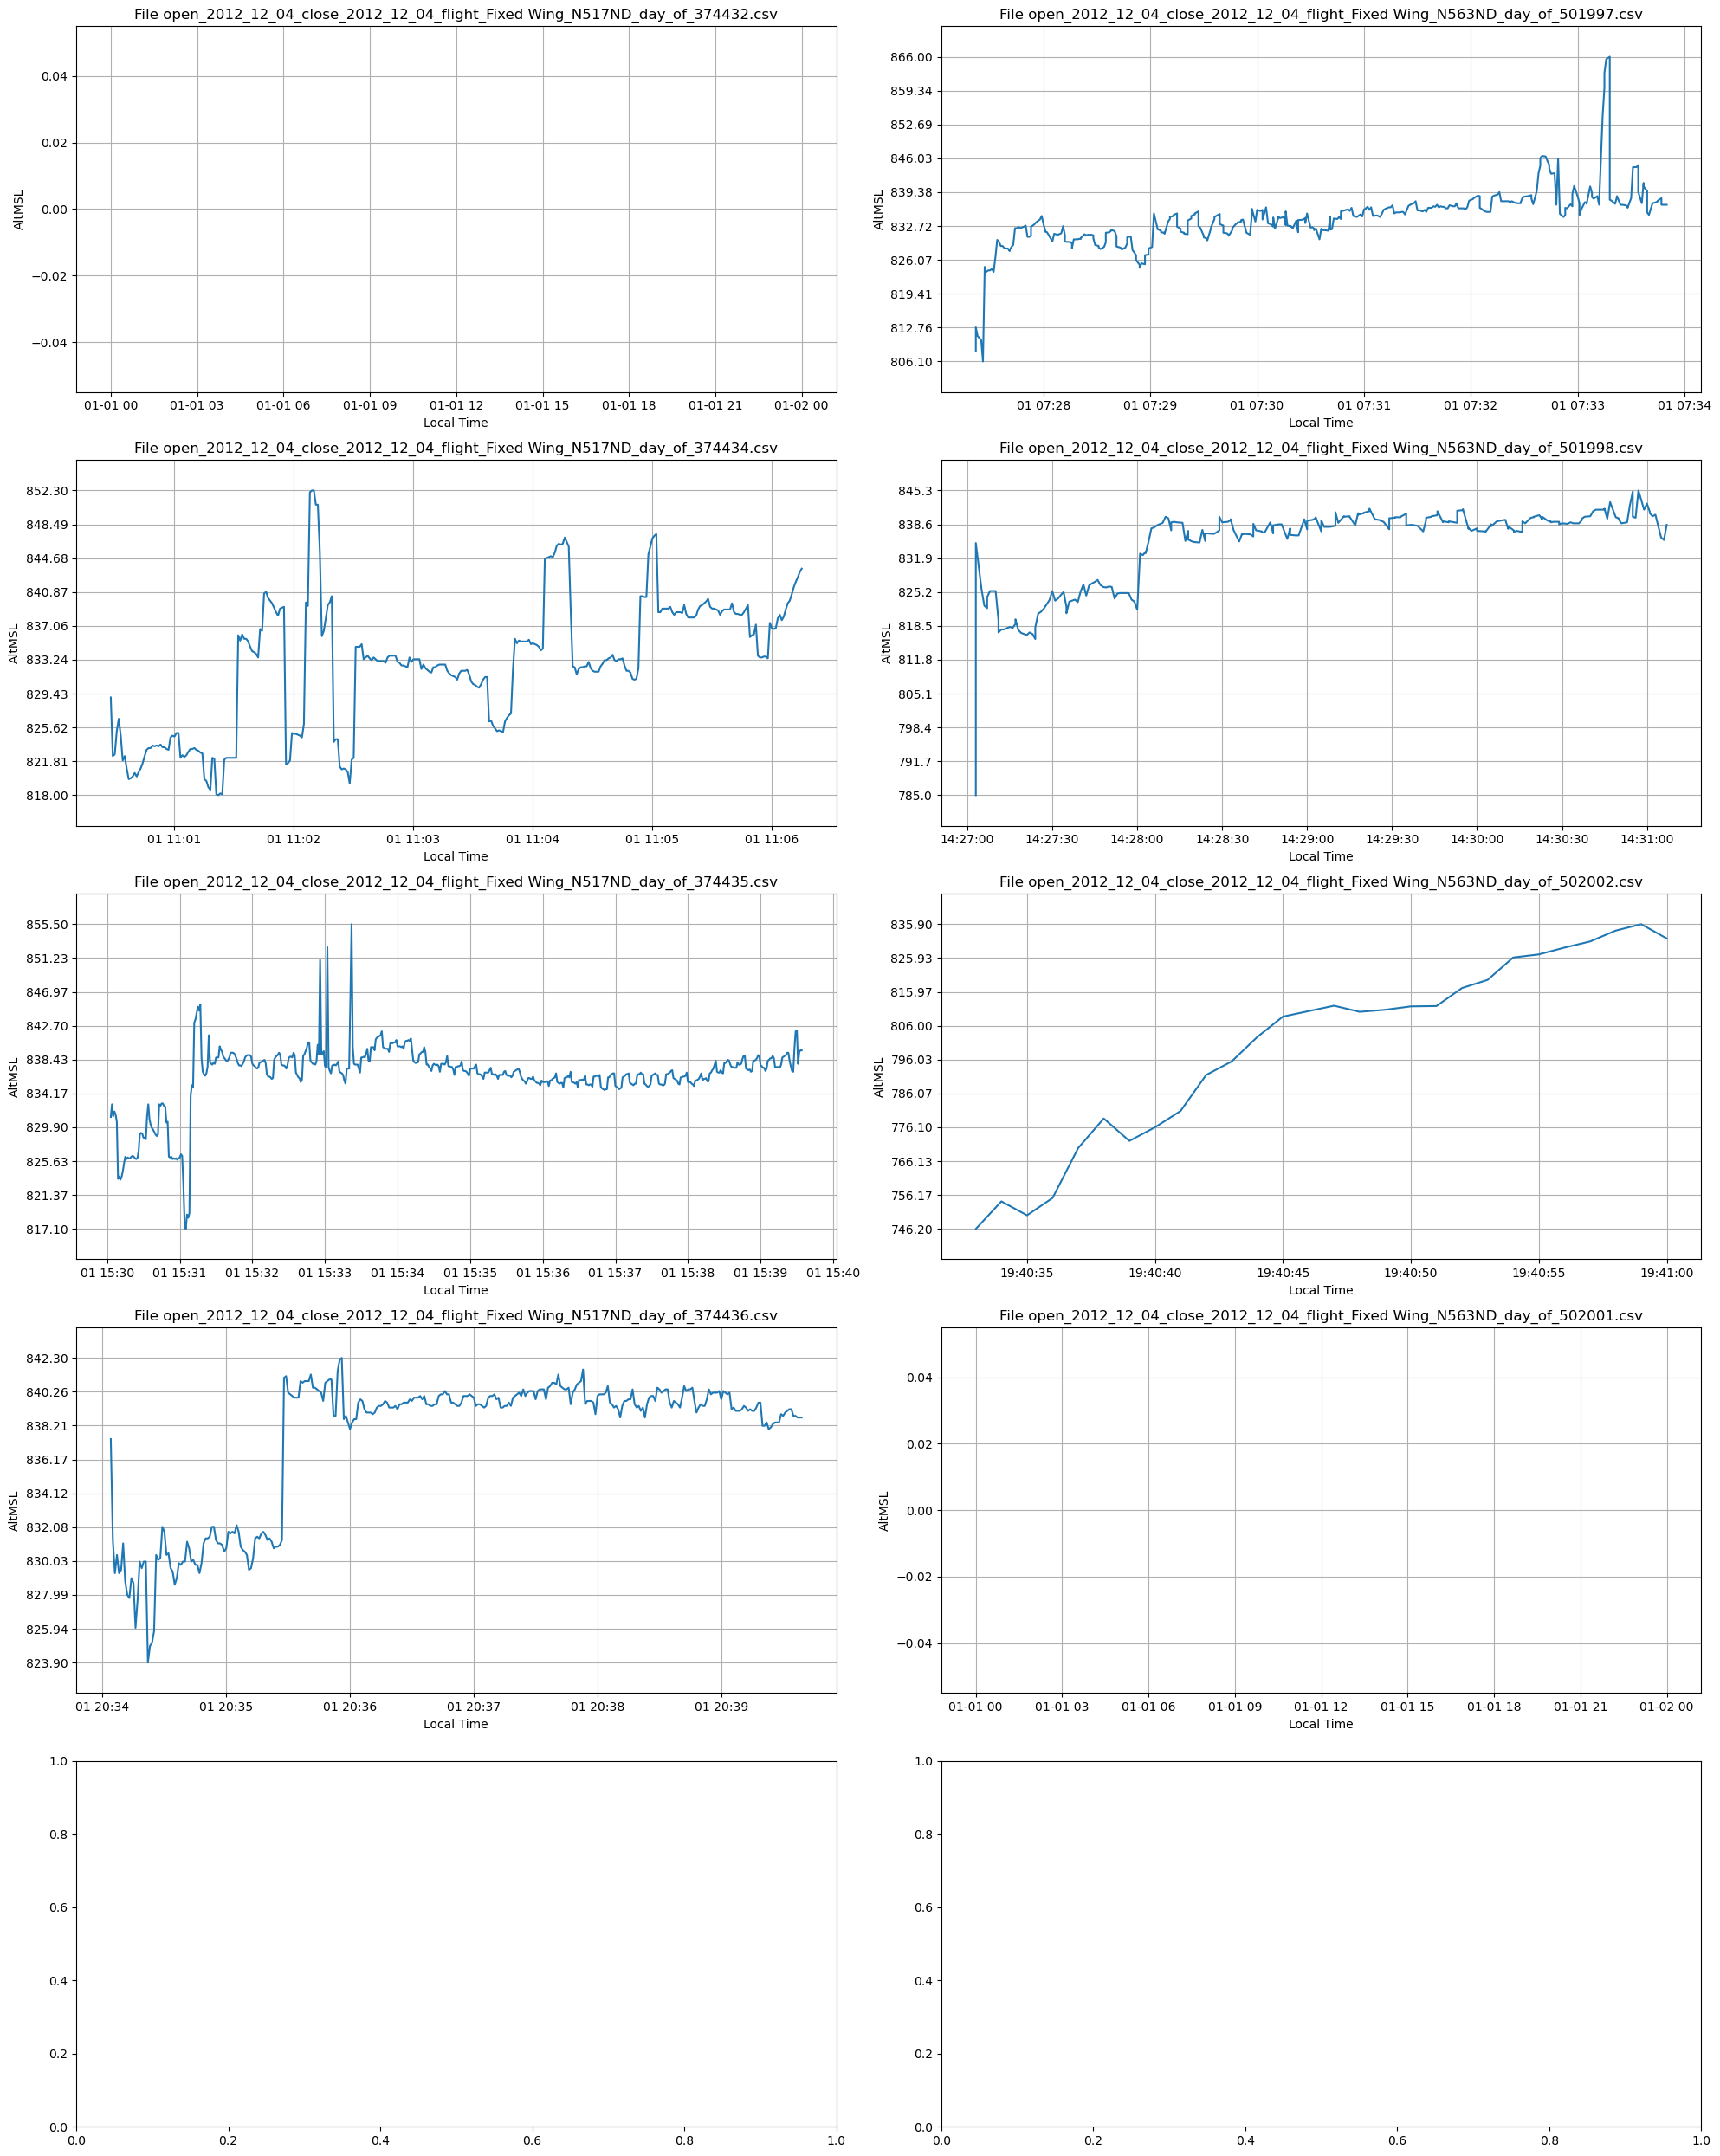

In [ ]:

# Number of files to plot
N_FILES = len(file_paths)

# Create a tile-based plot for all files in file_paths
fig, axs = plt.subplots(nrows=5, ncols=2, figsize=(20, 25))

for i, file in enumerate(file_paths[:N_FILES]):
    df = pd.read_csv(file, skiprows=2)
    # Strip the leading and trailing whitespaces from the column names
    df.columns = df.columns.str.strip()
    # Strip the leading and trailing whitespaces from the 'Lcl Time' field and convert to datetime format
    df['Lcl Time'] = pd.to_datetime(df['Lcl Time'].str.strip(), format='%H:%M:%S')
    # Convert 'AltMSL' to numeric, setting errors='coerce' to handle non-numeric values
    df['AltMSL'] = pd.to_numeric(df['AltMSL'], errors='coerce')
    
    # Remove NaN values from 'AltMSL'
    df = df.dropna(subset=['AltMSL'])
    
    row = i // 2
    col = i % 2
    axs[row, col].plot(df['Lcl Time'], df['AltMSL'])
    axs[row, col].set_title(f'File {file}')
    axs[row, col].set_xlabel('Local Time')
    axs[row, col].set_ylabel('AltMSL')
    axs[row, col].grid(True)
    # Set Y-axis limits and ticks
    if not df['AltMSL'].empty:
        y_min = df['AltMSL'].min()
        y_max = df['AltMSL'].max()
        y_range = y_max - y_min
        axs[row, col].set_ylim(y_min - 0.1 * y_range, y_max + 0.1 * y_range)
        axs[row, col].set_yticks(np.linspace(y_min, y_max, num=10))

plt.tight_layout()
plt.show()

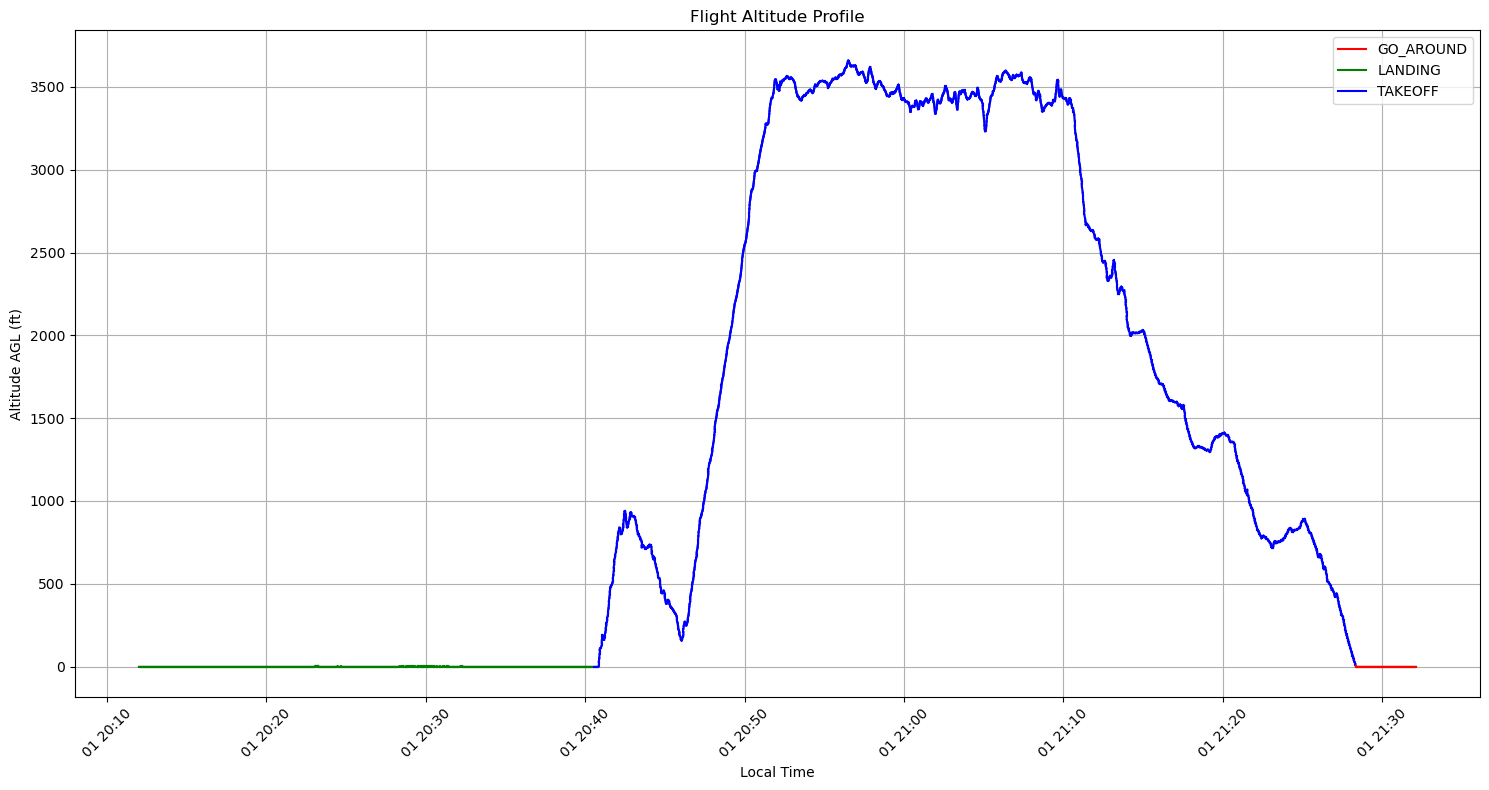

In [14]:
'''
To get an idea of the flight phases, we can plot the altitude profile for a labeled flight
'''
# Read the labeled flight data
df = pd.read_csv('/Users/manasdubey2022/Desktop/open_2013_05_22_close_2013_05_23_flight_Fixed Wing_N507ND_day_of_143555_Labeled.csv')

# Convert time to datetime
df['Lcl Time'] = pd.to_datetime(df['Lcl Time'].str.strip(), format='%H:%M:%S')

# Create figure
plt.figure(figsize=(15, 8))

# Create a single line plot
plt.plot(df['Lcl Time'], df['AltitudeAGL'], 'k-', alpha=0.2)  # Plot base line in light gray

# Color segments based on flight phase
unique_phases = df['FlightPhase'].unique()
colors = ['red', 'green', 'blue', 'orange']
color_map = {phase: color for phase, color in zip(unique_phases, colors)}

for i in range(len(df)-1):
    phase = df['FlightPhase'].iloc[i]
    plt.plot(df['Lcl Time'].iloc[i:i+2], 
            df['AltitudeAGL'].iloc[i:i+2],
            color=color_map[phase],
            label=phase if phase not in plt.gca().get_legend_handles_labels()[1] else "")

plt.title('Flight Altitude Profile')
plt.xlabel('Local Time')
plt.ylabel('Altitude AGL (ft)')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [24]:
# List to store files with completely NaN 'AltMSL' column
files_with_nan_altmsl = []

# Loop through each file and check if 'AltMSL' column is completely NaN
for file in csv_files:
    df = pd.read_csv(file, skiprows=2, low_memory=False) # low_memory=False to suppress warning , this 
    df.columns = df.columns.str.strip()
    df['AltMSL'] = pd.to_numeric(df['AltMSL'], errors='coerce')
    if df['AltMSL'].isna().all():
        files_with_nan_altmsl.append(file)

print("Files with completely NaN 'AltMSL' column:")
for file in files_with_nan_altmsl:
    print(file)



Files with completely NaN 'AltMSL' column:
/Users/manasdubey2022/Desktop/NGAFID/c_37/open_2013_12_26_close_2013_12_29_flight_Fixed Wing_N564ND_day_of_398792.csv
/Users/manasdubey2022/Desktop/NGAFID/c_37/open_2015_06_01_close_2015_06_01_flight_Fixed Wing_N608ND_day_of_351996.csv
/Users/manasdubey2022/Desktop/NGAFID/c_37/open_2014_03_18_close_2014_03_18_flight_Fixed Wing_N570ND_day_of_337831.csv
/Users/manasdubey2022/Desktop/NGAFID/c_37/open_2013_09_09_close_2013_09_09_flight_Fixed Wing_N525ND_day_of_237319.csv
/Users/manasdubey2022/Desktop/NGAFID/c_37/open_2015_06_22_close_2015_06_23_flight_Fixed Wing_N511ND_day_of_415506.csv
/Users/manasdubey2022/Desktop/NGAFID/c_37/open_2014_07_08_close_2014_07_08_flight_Fixed Wing_N573ND_day_of_389216.csv
/Users/manasdubey2022/Desktop/NGAFID/c_37/open_2013_09_09_close_2013_09_09_flight_Fixed Wing_N525ND_day_of_237318.csv
/Users/manasdubey2022/Desktop/NGAFID/c_37/open_2014_05_22_close_2014_05_22_flight_Fixed Wing_N575ND_day_of_291681.csv
/Users/manasd

In [33]:
# Read the file names and their IDs from the text file
file_id_map = {}
with open('file_names.txt', 'r') as f:
    for line in f:
        idx, file_path = line.strip().split(': ')
        file_id_map[file_path] = idx

# Save the list of files with completely NaN 'AltMSL' column using their IDs
with open('files_with_nan_altmsl_ids.txt', 'w') as f:
    for file in files_with_nan_altmsl:
        file_id = file_id_map.get(file, 'Unknown ID')
        f.write(f'{file_id}: {file}\n')

# Loading all day of events files

In [1]:
import pandas as pd
import glob
import os



# Define the path to the folder containing the CSV files
folder_path = '/Users/manasdubey2022/Desktop/NGAFID/c_37'

# Find all CSV files matching the pattern *_day_of_*.csv
csv_files = glob.glob(os.path.join(folder_path, '*_day_of_*.csv'))

In [2]:



N_FILES = len(csv_files)

# Count the number of files
print(f"Total number of files: {N_FILES}")

# # Initialize variables to store the total number of rows and the combined DataFrame
# total_rows = 0
# combined_df = pd.DataFrame()
# first_file_last_row = 0

# # Loop through each file and concatenate them into one DataFrame
# for idx, file in enumerate(csv_files[:N_FILES]):
#     df = pd.read_csv(file, skiprows=2)
#     # Add a unique identifier to each row based on the file index
#     df['id'] = f'file_{idx}'
    
#     total_rows += len(df)
#     first_file_last_row = len(df)

#     combined_df = pd.concat([combined_df, df], ignore_index=True)
    
# # Print the data types of the columns and check if any columns have multiple data types
# print(combined_df.dtypes)
# #save the combined dataframe to a new CSV file
# combined_df.to_csv('combined_data.csv', index=False)

Total number of files: 1676


In [4]:
#get the number of rows in files_with_nan_altmsl_ids.txt
num_rows = 0
with open('files_with_nan_altmsl_ids.txt', 'r') as f:
    num_rows = len(f.readlines())
    
print(f"Number of rows in files_with_nan_altmsl_ids.txt: {num_rows}")


Number of rows in files_with_nan_altmsl_ids.txt: 239


In [1]:
import pandas as pd
c_37_day_of_df = pd.read_csv('/Users/manasdubey2022/Desktop/NGAFID/Codebase/data/combined_data.csv')
c_37_day_of_df.head()


/var/folders/k_/mxrh7nj55tl1jtzf2n_d0swm0000gn/T/ipykernel_22071/1238672616.py:2: DtypeWarning: Columns (4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,40,41,42,43,44,45,47,48,49,50,51,52,57,59,61,62,63,65,66,67,68,69,70,71,72,73,74,75) have mixed types. Specify dtype option on import or set low_memory=False.
  c_37_day_of_df = pd.read_csv('/Users/manasdubey2022/Desktop/NGAFID/Codebase/data/combined_data.csv')


,Lcl Date,Lcl Time,UTCOfst,AtvWpt,Latitude,Longitude,AltB,BaroA,AltMSL,OAT,...,E2 FFlow,E2 OilT,E2 OilP,E2 MAP,E2 RPM,E2 CHT1,E2 EGT1,E2 EGT2,E2 EGT3,E2 EGT4
0,2015-03-05,18:52:22,-06:00,,47.9485893,-97.1724472,1050.8,30.33,840.0,-7.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-03-05,18:52:22,-06:00,,47.9485893,-97.1724472,1050.8,30.33,840.0,-7.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-03-05,18:52:24,-06:00,,47.9485855,-97.1724472,1050.8,30.33,839.9,-7.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2015-03-05,18:52:25,-06:00,,47.9485855,-97.1724472,1051.8,30.33,839.9,-7.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2015-03-05,18:52:25,-06:00,,47.9485855,-97.1724472,1051.8,30.33,839.8,-7.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
c_37_day_of_df.columns = c_37_day_of_df.columns.str.strip()

In [3]:
c_37_day_of_df.columns

Index(['Lcl Date', 'Lcl Time', 'UTCOfst', 'AtvWpt', 'Latitude', 'Longitude',
       'AltB', 'BaroA', 'AltMSL', 'OAT', 'IAS', 'GndSpd', 'VSpd', 'Pitch',
       'Roll', 'LatAc', 'NormAc', 'HDG', 'TRK', 'volt1', 'volt2', 'amp1',
       'amp2', 'FQtyL', 'FQtyR', 'E1 FFlow', 'E1 OilT', 'E1 OilP', 'E1 RPM',
       'E1 CHT1', 'E1 CHT2', 'E1 CHT3', 'E1 CHT4', 'E1 EGT1', 'E1 EGT2',
       'E1 EGT3', 'E1 EGT4', 'AltGPS', 'TAS', 'HSIS', 'CRS', 'NAV1', 'NAV2',
       'COM1', 'COM2', 'HCDI', 'VCDI', 'WndSpd', 'WndDr', 'WptDst', 'WptBrg',
       'MagVar', 'AfcsOn', 'RollM', 'PitchM', 'RollC', 'PichC', 'VSpdG',
       'GPSfix', 'HAL', 'VAL', 'HPLwas', 'HPLfd', 'VPLwas', 'id', 'E1 MAP',
       'E2 FFlow', 'E2 OilT', 'E2 OilP', 'E2 MAP', 'E2 RPM', 'E2 CHT1',
       'E2 EGT1', 'E2 EGT2', 'E2 EGT3', 'E2 EGT4'],
      dtype='object')

In [4]:
# Clean the data (if necessary)
c_37_day_of_df['Lcl Date'] = c_37_day_of_df['Lcl Date'].str.strip()
c_37_day_of_df['Lcl Time'] = c_37_day_of_df['Lcl Time'].str.strip()

# Combine the date and time columns again
c_37_day_of_df['Lcl DateTime'] = c_37_day_of_df['Lcl Date'] + ' ' + c_37_day_of_df['Lcl Time']

# Convert to datetime
c_37_day_of_df['Lcl DateTime'] = pd.to_datetime(c_37_day_of_df['Lcl DateTime'], format='%Y-%m-%d %H:%M:%S', errors='coerce')

# Check the result
print(c_37_day_of_df['Lcl DateTime'])

0         2015-03-05 18:52:22
1         2015-03-05 18:52:22
2         2015-03-05 18:52:24
3         2015-03-05 18:52:25
4         2015-03-05 18:52:25
                  ...        
3020462   2013-06-26 15:20:06
3020463   2013-06-26 15:20:07
3020464   2013-06-26 15:20:08
3020465   2013-06-26 15:20:09
3020466   2013-06-26 15:20:10
Name: Lcl DateTime, Length: 3020467, dtype: datetime64[ns]


/var/folders/k_/mxrh7nj55tl1jtzf2n_d0swm0000gn/T/ipykernel_22071/3029842805.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df['Hour'] = combined_df['Lcl DateTime'].dt.hour
/var/folders/k_/mxrh7nj55tl1jtzf2n_d0swm0000gn/T/ipykernel_22071/3029842805.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df['Minute'] = combined_df['Lcl DateTime'].dt.minute
/var/folders/k_/mxrh7nj55tl1jtzf2n_d0swm0000gn/T/ipykernel_22071/3029842805.py:9: SettingWithCopyWarning: 
A value is trying to be set o

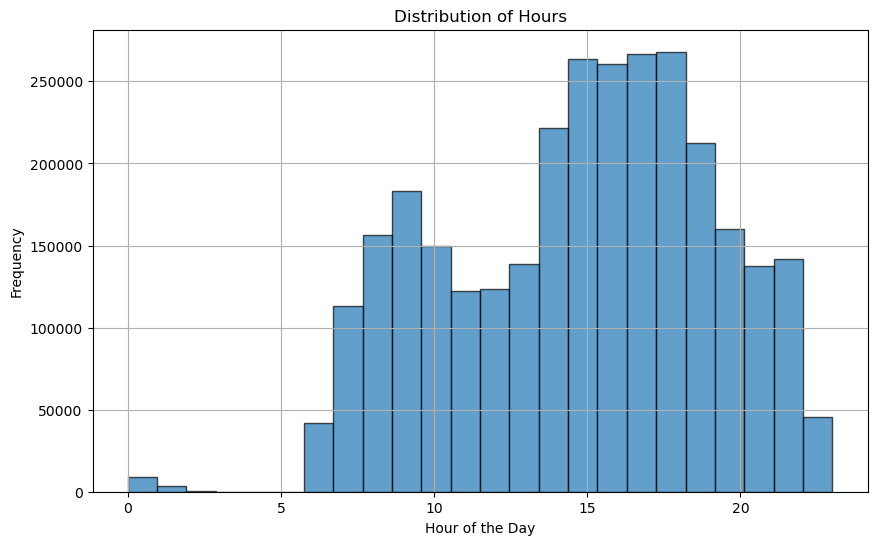

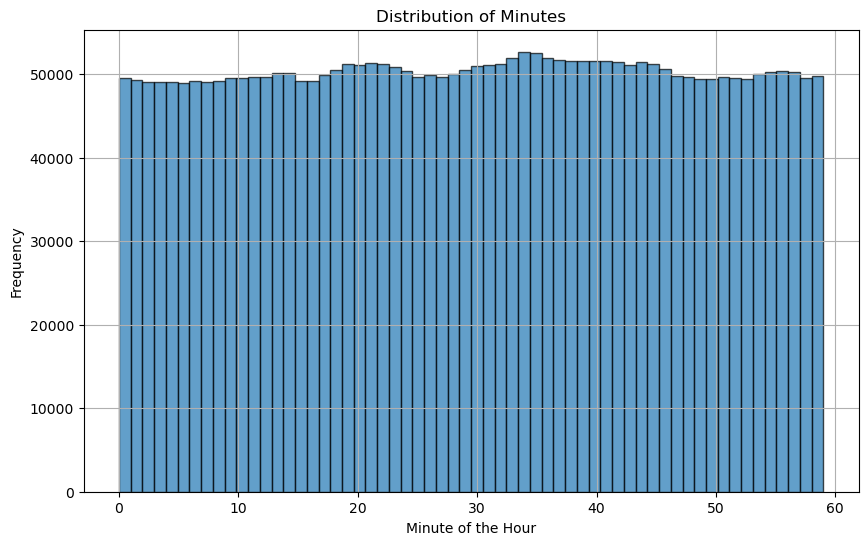

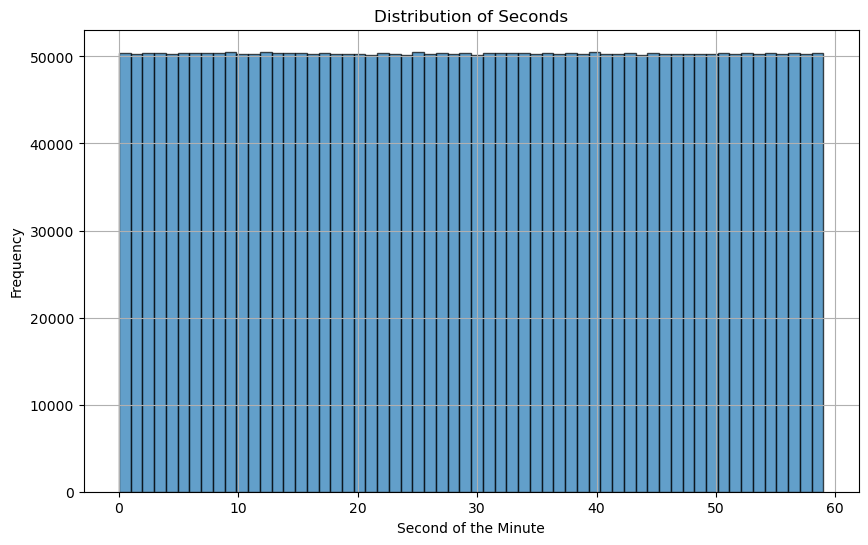

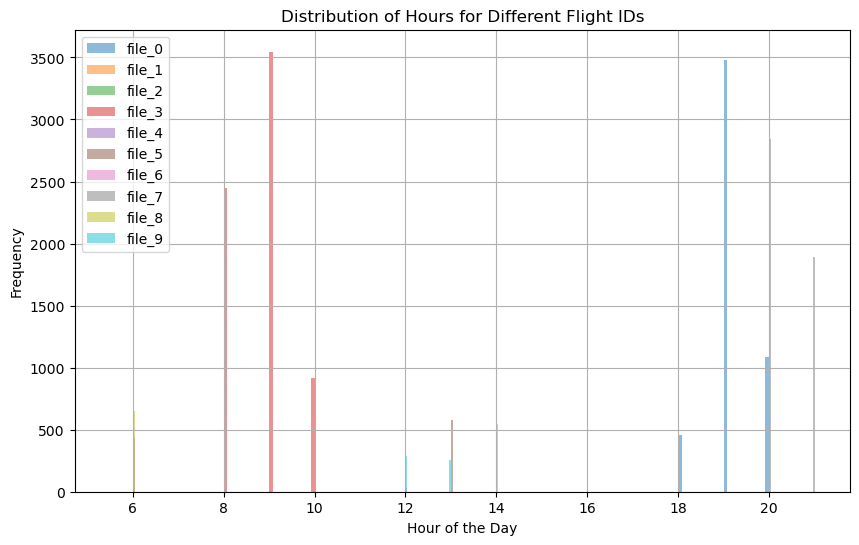

In [5]:
import matplotlib.pyplot as plt

# Drop NaN values
combined_df = c_37_day_of_df.dropna(subset=['Lcl DateTime'])

# Extract hour, minute, and second from 'Lcl DateTime'
combined_df['Hour'] = combined_df['Lcl DateTime'].dt.hour
combined_df['Minute'] = combined_df['Lcl DateTime'].dt.minute
combined_df['Second'] = combined_df['Lcl DateTime'].dt.second

# Plot the distribution of hours
plt.figure(figsize=(10, 6))
combined_df['Hour'].hist(bins=24, edgecolor='k', alpha=0.7)
plt.title('Distribution of Hours')
plt.xlabel('Hour of the Day')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Plot the distribution of minutes
plt.figure(figsize=(10, 6))
combined_df['Minute'].hist(bins=60, edgecolor='k', alpha=0.7)
plt.title('Distribution of Minutes')
plt.xlabel('Minute of the Hour')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Plot the distribution of seconds
plt.figure(figsize=(10, 6))
combined_df['Second'].hist(bins=60, edgecolor='k', alpha=0.7)
plt.title('Distribution of Seconds')
plt.xlabel('Second of the Minute')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Plot the distribution of times for different flight 'id'
plt.figure(figsize=(10, 6))
for flight_id in combined_df['id'].unique()[:10]:  # Plotting for first 10 unique flight ids for clarity
    subset = combined_df[combined_df['id'] == flight_id]
    subset['Hour'].hist(bins=24, alpha=0.5, label=flight_id)

plt.title('Distribution of Hours for Different Flight IDs')
plt.xlabel('Hour of the Day')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()


In [6]:
from collections import defaultdict

# Create a dictionary to store the date and corresponding set of unique 'id's
date_id_dict = defaultdict(set)

# Loop through each row in the dataframe
for index, row in combined_df.iterrows():
    date = row['Lcl Date']
    flight_id = row['id']
    date_id_dict[date].add(flight_id)

# Convert defaultdict to a regular dictionary
date_id_dict = {date: list(ids) for date, ids in date_id_dict.items()}

# Print the dictionary
for date, ids in date_id_dict.items():
    print(f"Date: {date}, Unique IDs: {ids}")

Date: 2015-03-05, Unique IDs: ['file_173', 'file_274', 'file_80', 'file_0']
Date: 2014-03-18, Unique IDs: ['file_1', 'file_151', 'file_61', 'file_397', 'file_487', 'file_78', 'file_97', 'file_20', 'file_1098']
Date: 2014-02-02, Unique IDs: ['file_277', 'file_2', 'file_170']
Date: 2012-10-30, Unique IDs: ['file_1312', 'file_1463', 'file_1559', 'file_3']
Date: 2014-09-23, Unique IDs: ['file_77', 'file_4', 'file_162']
Date: 2014-03-23, Unique IDs: ['file_5', 'file_88', 'file_75']
Date: 2013-12-26, Unique IDs: ['file_76', 'file_86', 'file_159', 'file_6']
Date: 2013-05-23, Unique IDs: ['file_178', 'file_638', 'file_802', 'file_592', 'file_519', 'file_500', 'file_1182', 'file_72', 'file_7', 'file_695', 'file_269']
Date: 2017-04-10, Unique IDs: ['file_571', 'file_1280', 'file_1037', 'file_1181', 'file_687', 'file_914', 'file_276', 'file_8', 'file_1216', 'file_29']
Date: 2016-03-29, Unique IDs: ['file_372', 'file_70', 'file_9']
Date: 2013-10-04, Unique IDs: ['file_1367', 'file_92', 'file_10', 

Date with the most number of unique flights: 2013-04-02, Count: 19
Date with the least number of unique flights: 2015-02-28, Count: 1
Average number of unique flights per day: 3.826879271070615


Text(0.5, 0, 'Number of Unique Flights')

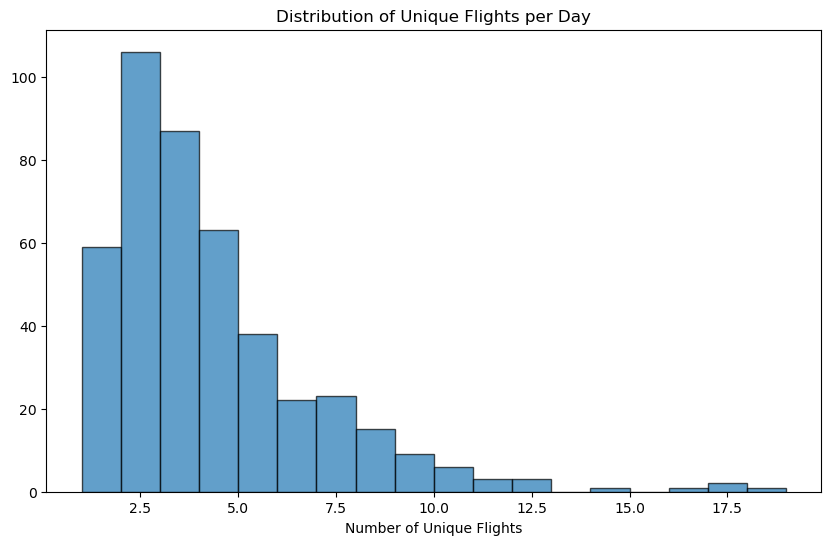

In [14]:
#Generate basic statistics for the above data (e.g.) the date with the most number of unique flights, the date with the least number of unique flights, the average number of unique flights per day, etc.
# Calculate the date with the most number of unique flights
max_flights_date = max(date_id_dict, key=lambda date: len(date_id_dict[date]))
max_flights_count = len(date_id_dict[max_flights_date])

# Calculate the date with the least number of unique flights
min_flights_date = min(date_id_dict, key=lambda date: len(date_id_dict[date]))
min_flights_count = len(date_id_dict[min_flights_date])

# Calculate the average number of unique flights per day    
total_flights = sum(len(ids) for ids in date_id_dict.values())
average_flights_per_day = total_flights / len(date_id_dict)

print(f"Date with the most number of unique flights: {max_flights_date}, Count: {max_flights_count}")
print(f"Date with the least number of unique flights: {min_flights_date}, Count: {min_flights_count}")
print(f"Average number of unique flights per day: {average_flights_per_day}")

# Plot the distribution of unique flights per day
unique_flights_per_day = [len(ids) for ids in date_id_dict.values()]

plt.figure(figsize=(10, 6))
plt.hist(unique_flights_per_day, bins=range(1, max(unique_flights_per_day) + 1), edgecolor='k', alpha=0.7)
plt.title('Distribution of Unique Flights per Day')
plt.xlabel('Number of Unique Flights')

In [9]:
# check from the combined_df ['file_188', 'file_299', 'file_259', 'file_17', 'file_367'] occur on the same date 2015-11-20
combined_df[combined_df['Lcl Date'] == '2015-11-20']['id'].unique()






array(['file_17', 'file_188', 'file_259', 'file_299', 'file_367'],
      dtype=object)

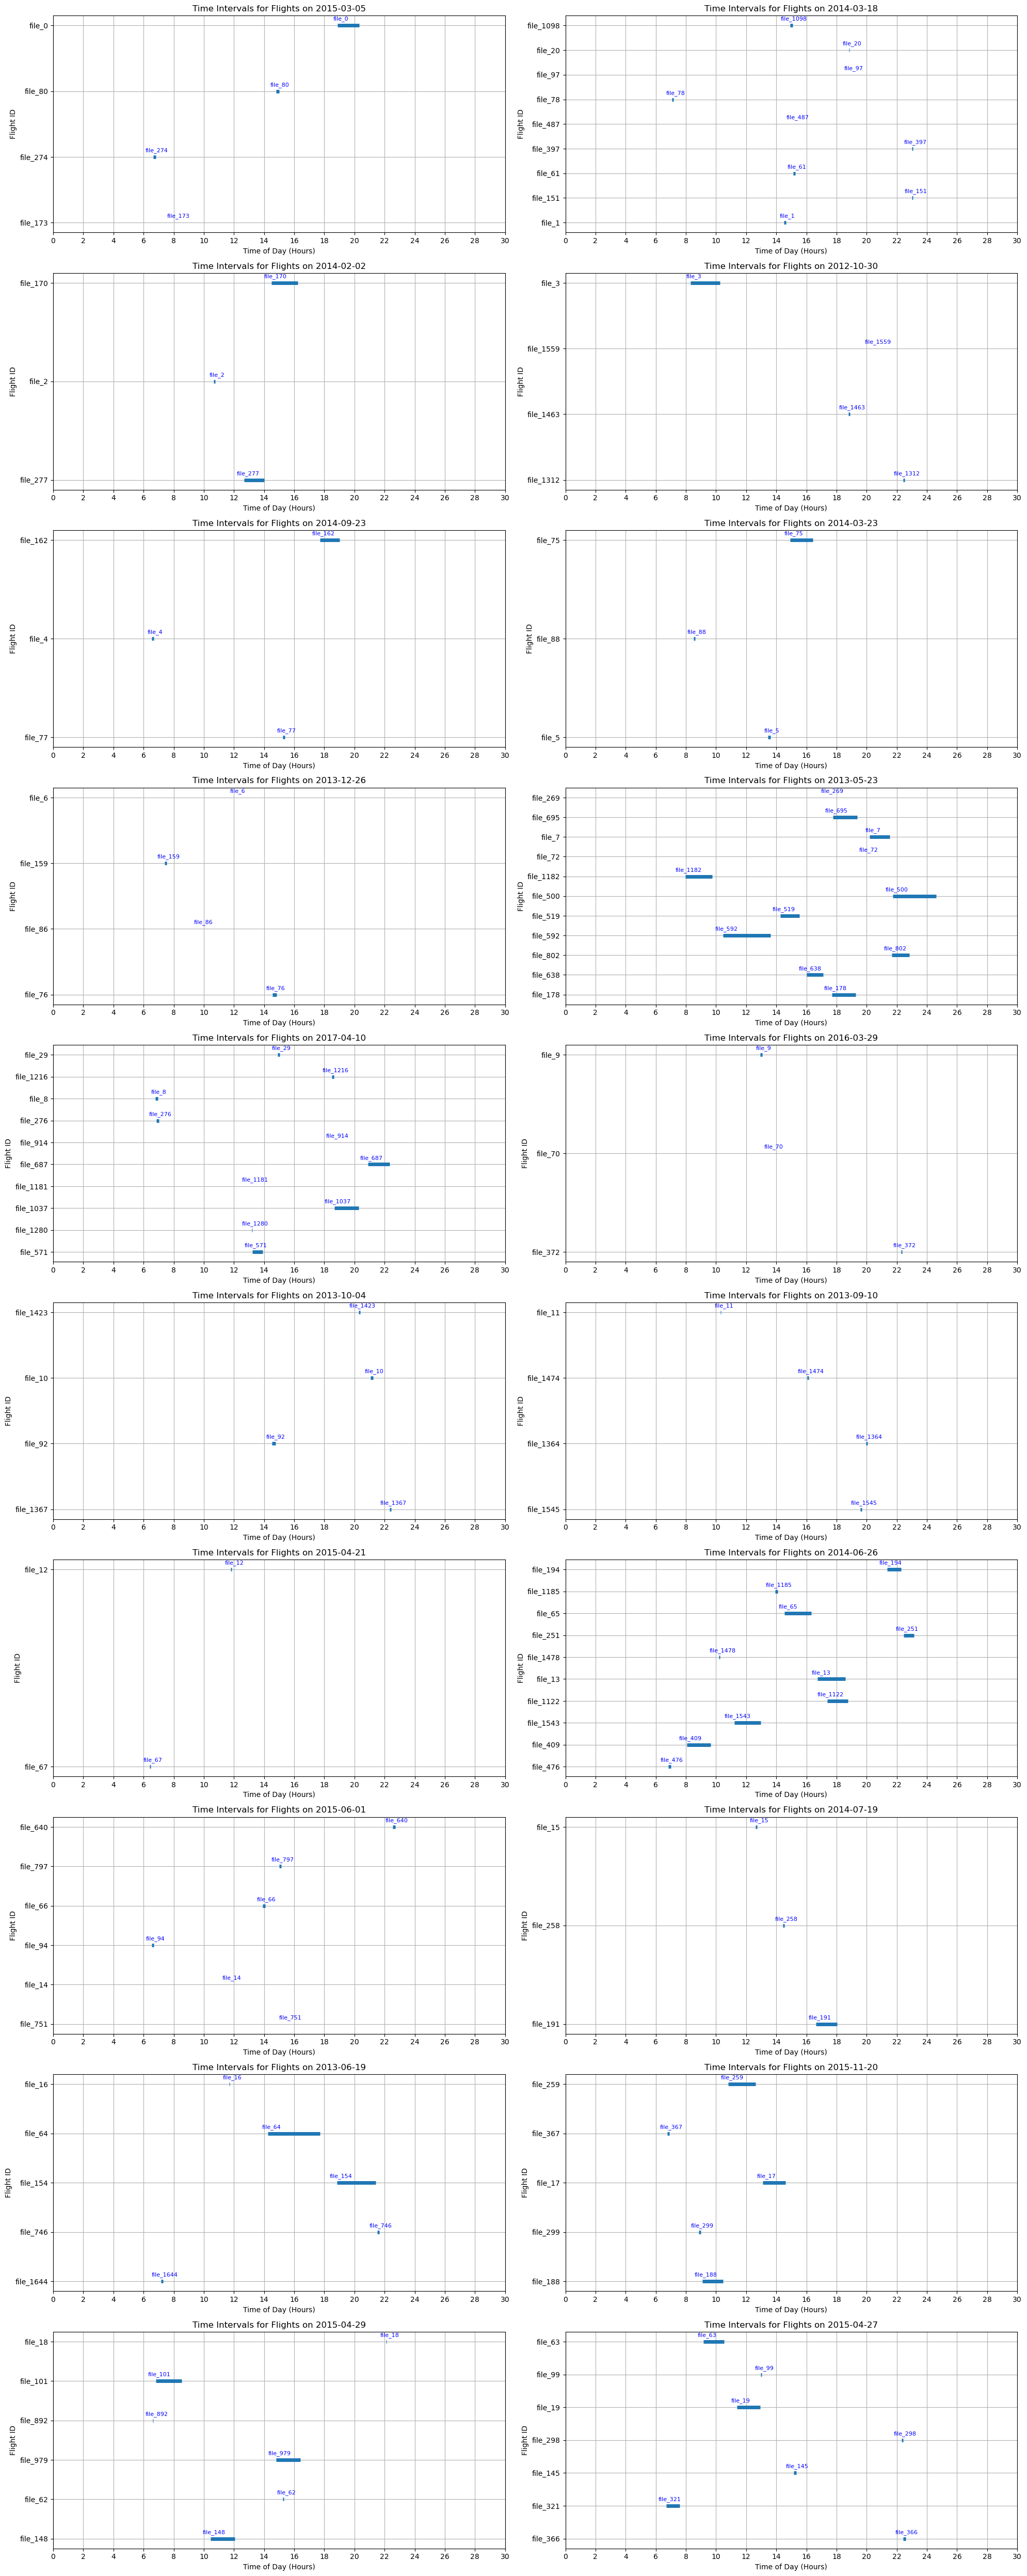

In [18]:
# Calculate the number of rows and columns for the subplot grid
"""
This script generates a grid of subplots to visualize the time intervals for flights on different dates.

The main steps are:
1. Define the number of rows and columns for the subplot grid.
2. Create a figure and a grid of subplots with the specified dimensions.
3. Iterate over the dates and corresponding flight IDs in the `date_id_dict` dictionary.
4. For each flight ID, filter the `combined_df` DataFrame to get the subset of data for that flight.
5. Calculate the minimum and maximum local date-time values for the flight.
6. Plot horizontal lines representing the time intervals for each flight on the corresponding subplot.
7. Annotate each line with the flight ID.
8. Set titles, labels, and grid for each subplot.
9. Break the loop if the maximum number of subplots is reached.
10. Adjust the layout and display the plot.
"""
N_ROWS = 10
N_COLS = 2

fig, axs = plt.subplots(nrows=N_ROWS, ncols=N_COLS, figsize=(20, 5 * N_ROWS))
for i, date in enumerate(date_id_dict.keys()):
    row = i // N_COLS
    col = i % N_COLS
    for flight_id in date_id_dict[date]:
        subset = combined_df[combined_df['id'] == flight_id]
        start_time = subset['Lcl DateTime'].min()
        end_time = subset['Lcl DateTime'].max()
        if end_time < start_time:
            end_time += pd.Timedelta(days=1)  # Adjust for flights that go past midnight
        time_intervals_seconds = [(start_time - pd.Timestamp(start_time.date())).total_seconds(),
                                  (end_time - pd.Timestamp(start_time.date())).total_seconds()]
        axs[row, col].hlines(y=flight_id, xmin=time_intervals_seconds[0] / 3600, xmax=time_intervals_seconds[1] / 3600, linewidth=5)
        axs[row, col].annotate(flight_id, xy=(time_intervals_seconds[0] / 3600, flight_id), xytext=(5, 5),
                               textcoords='offset points', ha='center', va='bottom', fontsize=8, color='blue')
    axs[row, col].set_title(f'Time Intervals for Flights on {date}')
    axs[row, col].set_xlabel('Time of Day (Hours)')
    axs[row, col].set_ylabel('Flight ID')
    axs[row, col].set_xticks(range(0, 31, 2))  # Set x-ticks to show every 2 hours, extending to 48 hours
    axs[row, col].grid(True)
    if i == N_ROWS * N_COLS - 1:
        break

plt.tight_layout()
plt.show()


In [15]:
#get the entry where file_188 occurs
combined_df[combined_df['id'] == 'file_500']

,Lcl Date,Lcl Time,UTCOfst,AtvWpt,Latitude,Longitude,AltB,BaroA,AltMSL,OAT,...,E2 RPM,E2 CHT1,E2 EGT1,E2 EGT2,E2 EGT3,E2 EGT4,Lcl DateTime,Hour,Minute,Second
1014997,2013-05-22,21:44:52,-05:00,,47.9485931,-97.1724396,583.0,29.81,849.2,15.8,...,NaN,NaN,NaN,NaN,NaN,NaN,2013-05-22 21:44:52,21,44,52
1014998,2013-05-22,21:44:52,-05:00,,47.9485931,-97.1724396,584.0,29.81,849.2,15.8,...,NaN,NaN,NaN,NaN,NaN,NaN,2013-05-22 21:44:52,21,44,52
1014999,2013-05-22,21:44:53,-05:00,,47.9485931,-97.1724396,585.0,29.81,848.6,15.8,...,NaN,NaN,NaN,NaN,NaN,NaN,2013-05-22 21:44:53,21,44,53
1015000,2013-05-22,21:44:54,-05:00,,47.9485931,-97.1724396,585.0,29.81,848.2,15.8,...,NaN,NaN,NaN,NaN,NaN,NaN,2013-05-22 21:44:54,21,44,54
1015001,2013-05-22,21:44:55,-05:00,,47.9485931,-97.1724396,584.0,29.81,847.7,15.8,...,NaN,NaN,NaN,NaN,NaN,NaN,2013-05-22 21:44:55,21,44,55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1025061,2013-05-23,00:36:16,-05:00,KFFM,47.948593,-97.172623,791.3,30.12,842.2,12.2,...,NaN,NaN,NaN,NaN,NaN,NaN,2013-05-23 00:36:16,0,36,16
1025062,2013-05-23,00:36:17,-05:00,KFFM,47.948593,-97.172615,791.3,30.12,841.9,12.2,...,NaN,NaN,NaN,NaN,NaN,NaN,2013-05-23 00:36:17,0,36,17
1025063,2013-05-23,00:36:18,-05:00,KFFM,47.948593,-97.172615,791.3,30.12,840.7,12.2,...,NaN,NaN,NaN,NaN,NaN,NaN,2013-05-23 00:36:18,0,36,18
1025064,2013-05-23,00:36:19,-05:00,KFFM,47.948593,-97.172615,792.3,30.12,840.6,12.2,...,NaN,NaN,NaN,NaN,NaN,NaN,2013-05-23 00:36:19,0,36,19


In [21]:
combined_df['Lcl Time']

0         NaT
1         NaT
2         NaT
3         NaT
4         NaT
           ..
3020462   NaT
3020463   NaT
3020464   NaT
3020465   NaT
3020466   NaT
Name: Lcl Time, Length: 3020467, dtype: datetime64[ns]

In [3]:
#print the unique values in the 'id' column
print(combined_df['id'].unique())

['file_0' 'file_1' 'file_2' ... 'file_1673' 'file_1674' 'file_1675']


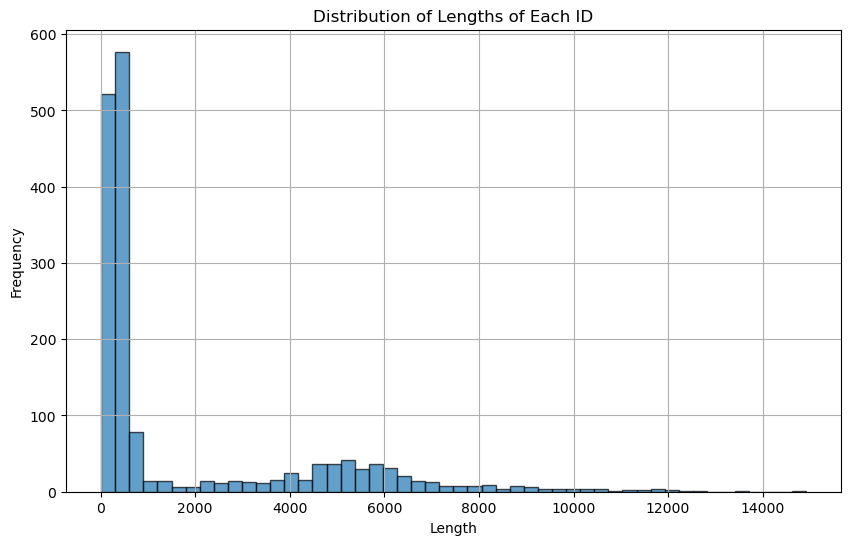

In [4]:
import matplotlib.pyplot as plt

# Calculate the length of each id
id_lengths = combined_df['id'].value_counts()

# Plot the distribution of the lengths
plt.figure(figsize=(10, 6))
plt.hist(id_lengths, bins=50, edgecolor='k', alpha=0.7)
plt.title('Distribution of Lengths of Each ID')
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()



ID closest to median length: file_884 with length 434


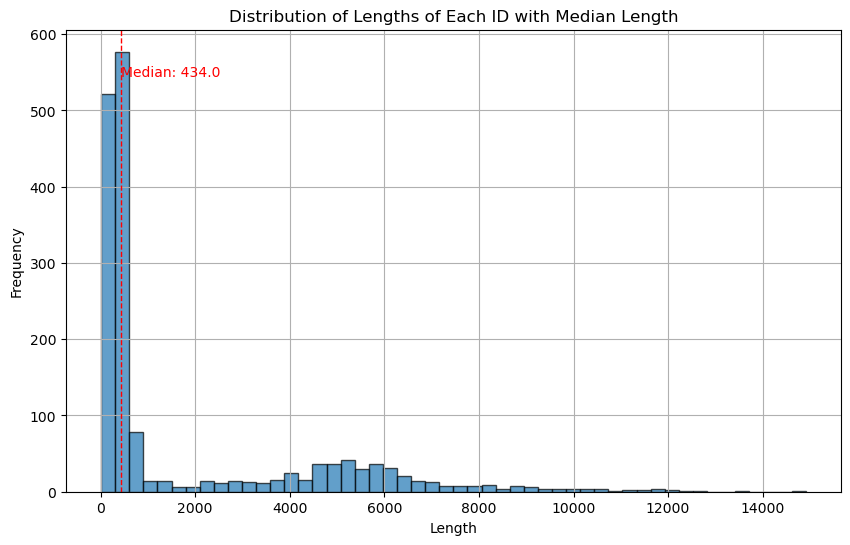

In [5]:
# Calculate the median length
median_length = id_lengths.median()

# Find the id with length closest to the median
closest_to_median_id = (id_lengths - median_length).abs().idxmin()
closest_to_median_length = id_lengths[closest_to_median_id]

print(f"ID closest to median length: {closest_to_median_id} with length {closest_to_median_length}")

# Plot the median length
plt.figure(figsize=(10, 6))
plt.hist(id_lengths, bins=50, edgecolor='k', alpha=0.7)
plt.axvline(median_length, color='r', linestyle='dashed', linewidth=1)
plt.text(median_length, plt.ylim()[1]*0.9, f'Median: {median_length}', color='r')
plt.title('Distribution of Lengths of Each ID with Median Length')
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [21]:
csv_1 = pd.read_csv(csv_files[0], skiprows=2)
csv_2 = pd.read_csv(csv_files[1], skiprows=2)

In [32]:
csv_2.iloc[0]

  Lcl Date          2014-03-18
 Lcl Time             14:30:11
 UTCOfst                -05:00
 AtvWpt                       
     Latitude                 
                     ...      
  HAL                   3704.0
   VAL                        
 HPLwas                       
 HPLfd                        
 VPLwas                       
Name: 0, Length: 64, dtype: object

In [23]:
csv_2

,Lcl Date,Lcl Time,UTCOfst,AtvWpt,Latitude,Longitude,AltB,BaroA,AltMSL,OAT,...,PitchM,RollC,PichC,VSpdG,GPSfix,HAL,VAL,HPLwas,HPLfd,VPLwas
0,2014-03-18,14:30:11,-05:00,,,,934.9,30.01,,10.5,...,,,,,NoSoln,3704.0,,,,
1,2014-03-18,14:30:12,-05:00,,,,934.9,30.01,,10.5,...,,,,,NoSoln,3704.0,,,,
2,2014-03-18,14:30:13,-05:00,,,,934.9,30.01,,10.2,...,,,,,NoSoln,3704.0,,,,
3,2014-03-18,14:30:14,-05:00,,,,934.9,30.01,,10.2,...,,,,,NoSoln,3704.0,,,,
4,2014-03-18,14:30:15,-05:00,,,,933.9,30.01,,10.0,...,,,,,NoSoln,3704.0,,,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
538,2014-03-18,14:39:13,-05:00,,47.9487610,-97.1718826,935.9,30.01,839.1,2.2,...,,,,0.0,3DDiff,3704.0,,12,15.0,15
539,2014-03-18,14:39:14,-05:00,,47.9487801,-97.1718903,935.9,30.01,839.1,2.2,...,,,,-3.9,3DDiff,3704.0,,12,15.0,15
540,2014-03-18,14:39:15,-05:00,,47.9487953,-97.1719055,936.9,30.01,838.8,2.2,...,,,,-7.9,3DDiff,3704.0,,12,15.5,16
541,2014-03-18,14:39:16,-05:00,,47.9488106,-97.1719131,936.9,30.01,840.5,2.2,...,,,,0.0,3DDiff,3704.0,,12,15.0,15


In [5]:
#go through the files in csv_files = glob.glob(os.path.join(folder_path, '*_day_of_*.csv'))
#plot the altitude profile for each file

# num_files = len(csv_files)
# nrows = num_files // 2
# ncols = 2

# fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 5 * nrows))

# for i, file in enumerate(csv_files):
#     df = pd.read_csv(file, skiprows=2)
#     axs[i // ncols, i % ncols].plot(df['AltMSL'])
#     axs[i // ncols, i % ncols].set_title(os.path.basename(file))
#     axs[i // ncols, i % ncols].set_xlabel('Index')
#     axs[i // ncols, i % ncols].set_ylabel('AltMSL')

# plt.tight_layout()
# plt.show()



NameError: name 'plt' is not defined

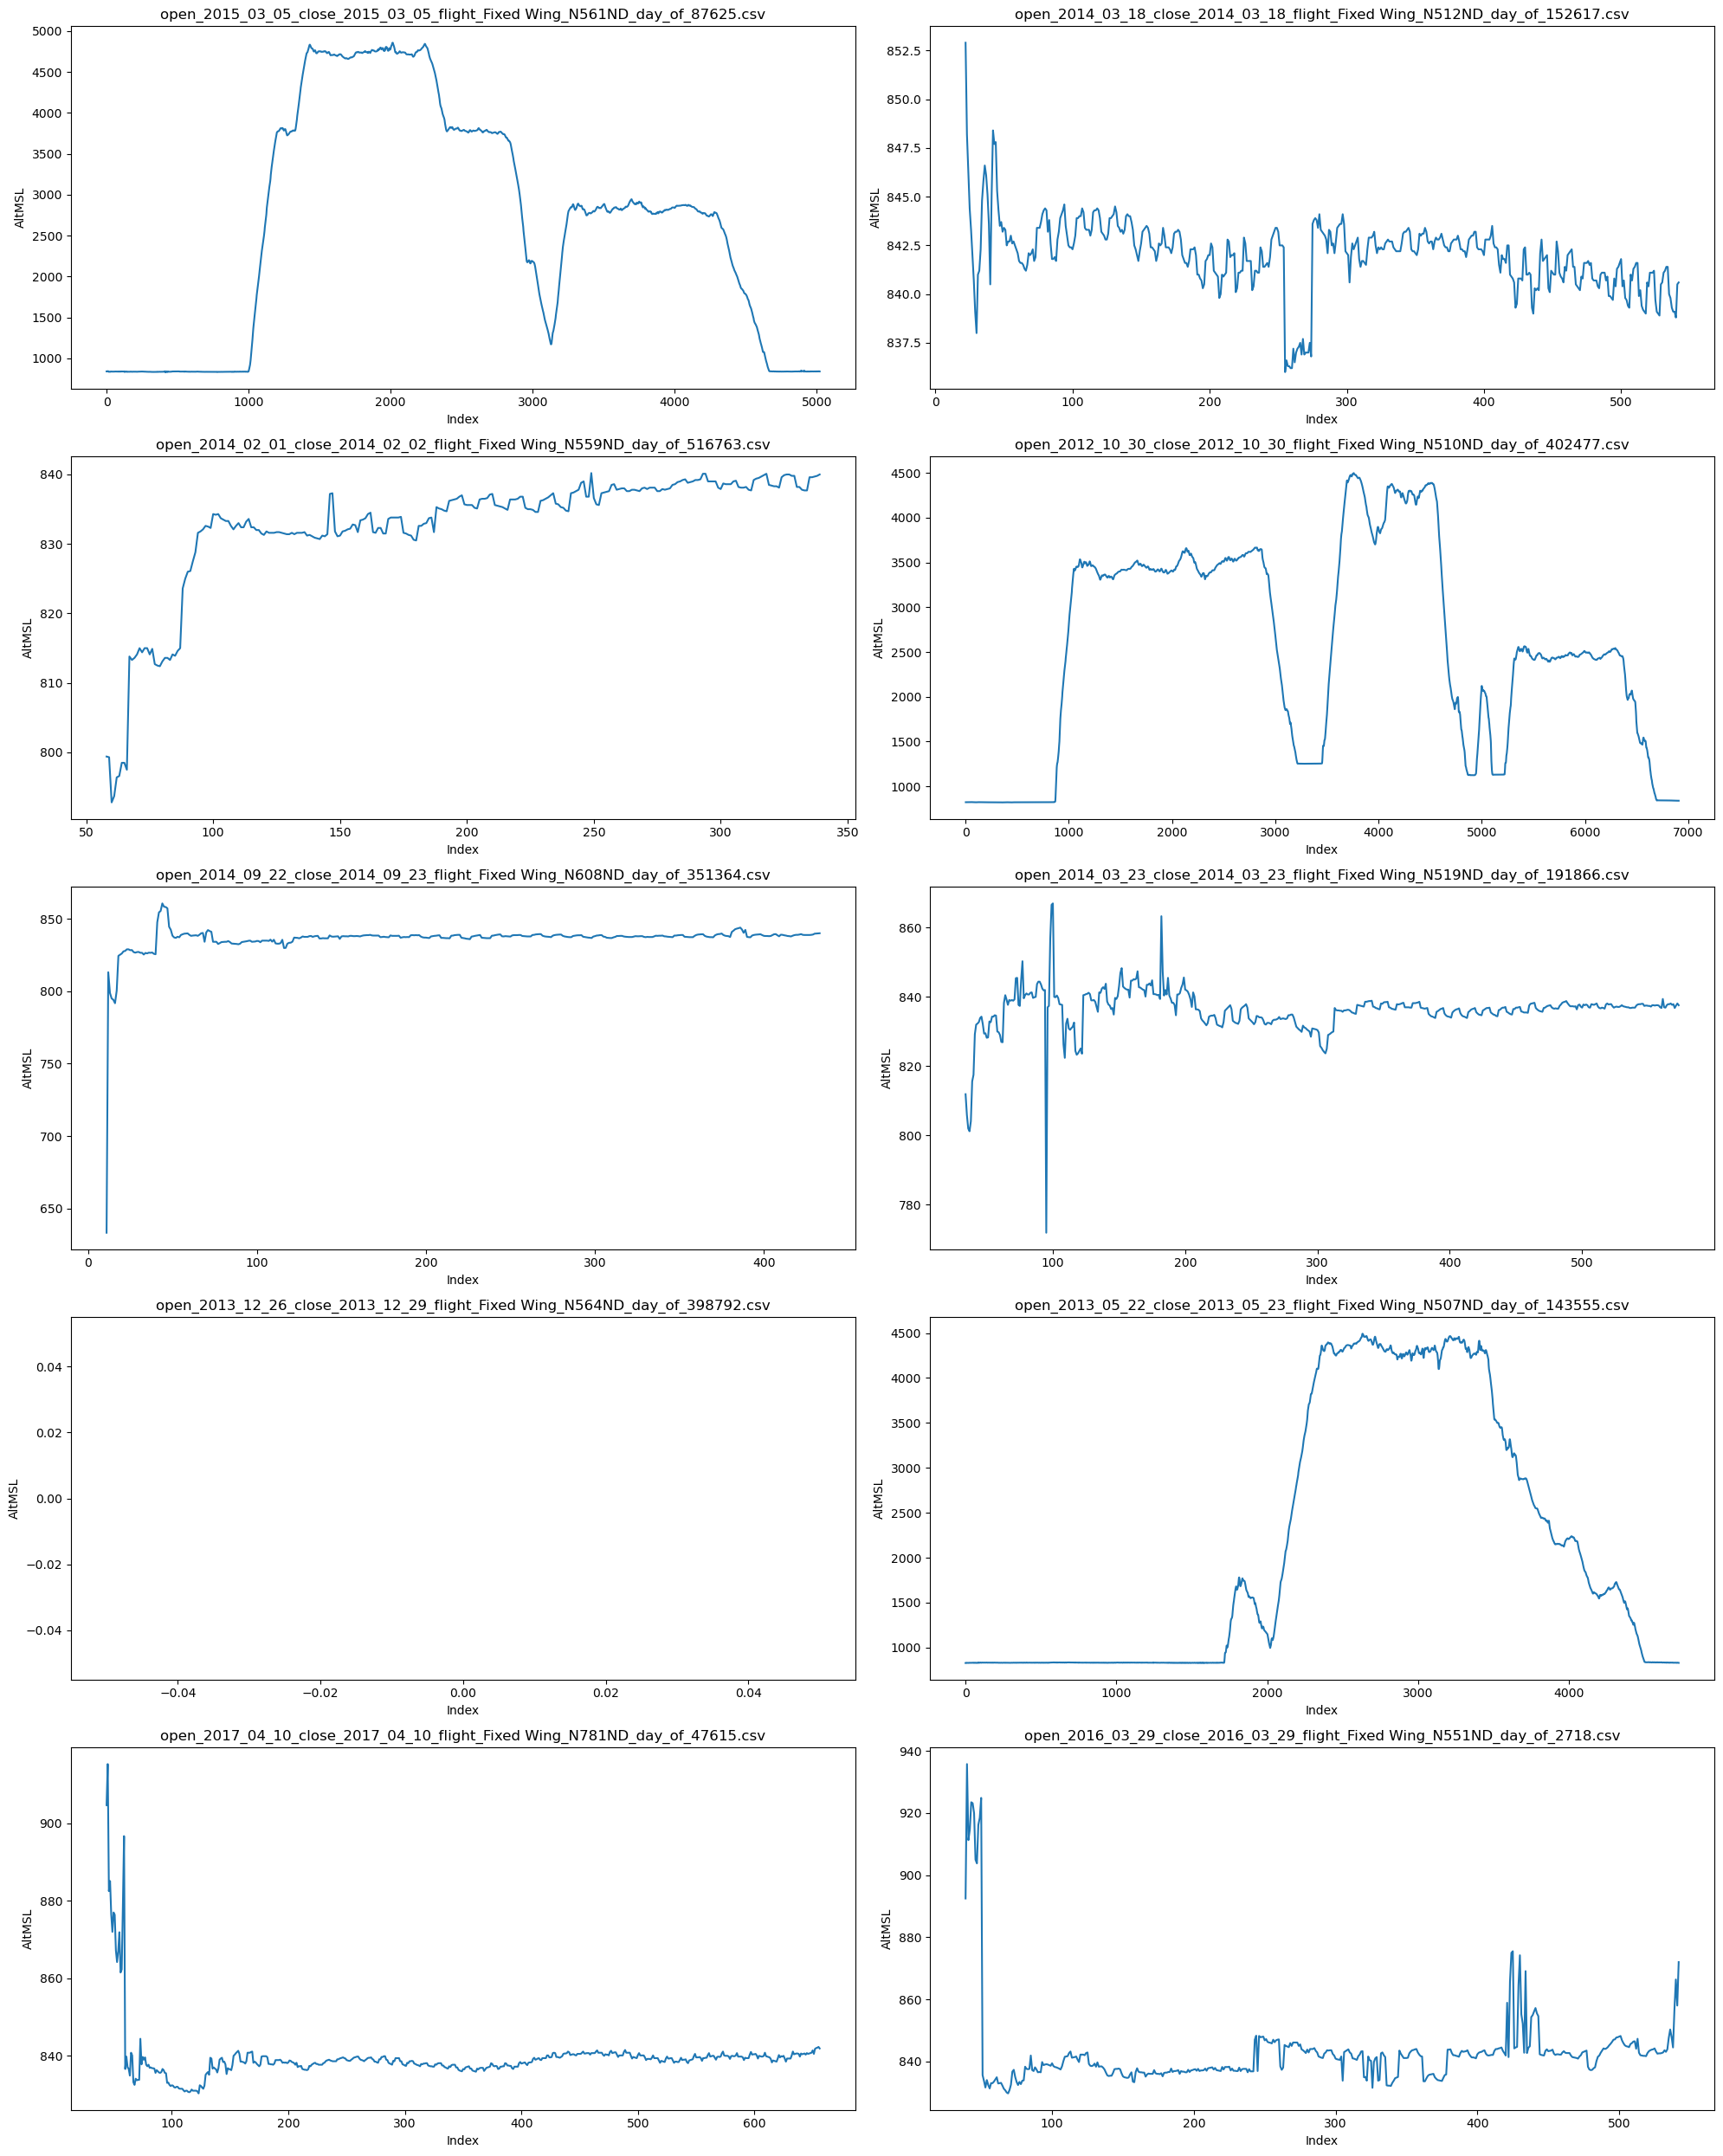

In [6]:

#To plot over combined_df from combined_data.csv

import matplotlib.pyplot as plt

N_FILES = 10
# Create a tile-based plot for all files in csv_files
fig, axs = plt.subplots(nrows=5, ncols=2, figsize=(20, 25))

for i, file in enumerate(csv_files[:N_FILES]):
    df = pd.read_csv(file, skiprows=2)
    # strip the leading and trailing whitespaces from the column names
    df.columns = df.columns.str.strip()
    # Convert 'AltMSL' to numeric, setting errors='coerce' to handle non-numeric values
    df['AltMSL'] = pd.to_numeric(df['AltMSL'], errors='coerce')
    row = i // 2
    col = i % 2
    axs[row, col].plot(df['AltMSL'])
    axs[row, col].set_title(os.path.basename(file))
    axs[row, col].set_xlabel('Index')
    axs[row, col].set_ylabel('AltMSL')

plt.tight_layout()
plt.show()

# Testing on DAY_OF_EVENTS

In [ ]:

import numpy as np
import random

import tensorflow.compat.v2 as tf

tf.enable_v2_behavior()
print(tf.__version__)
# print(tf.keras.__version__)

import tensorflow_datasets as tfds
import tensorflow_probability as tfp
print(tfp.__version__)
from tqdm.notebook import tqdm
tfk = tf.keras
tfkl = tf.keras.layers
tfpl = tfp.layers
tfd = tfp.distributions


from sklearn.model_selection import train_test_split, KFold
from sklearn import preprocessing

tfk = tf.keras
tfkl = tf.keras.layers
tfpl = tfp.layers
tfd = tfp.distributions


# import tensorflow_addons as tfa

import pandas as pd
import random
import shutil

## Conv-MHSA Model

In [ ]:
def point_wise_feed_forward_network(d_model, dff):
  return tf.keras.Sequential([
      tf.keras.layers.Dense(dff, activation='relu'),  # (batch_size, seq_len, dff)
      tf.keras.layers.Dense(d_model)  # (batch_size, seq_len, d_model)
  ])

def scaled_dot_product_attention(q, k, v, mask):
  """Calculate the attention weights.
  q, k, v must have matching leading dimensions.
  k, v must have matching penultimate dimension, i.e.: seq_len_k = seq_len_v.
  The mask has different shapes depending on its type(padding or look ahead)
  but it must be broadcastable for addition.

  Args:
    q: query shape == (..., seq_len_q, depth)
    k: key shape == (..., seq_len_k, depth)
    v: value shape == (..., seq_len_v, depth_v)
    mask: Float tensor with shape broadcastable
          to (..., seq_len_q, seq_len_k). Defaults to None.

  Returns:
    output, attention_weights
  """

  matmul_qk = tf.matmul(q, k, transpose_b=True)  # (..., seq_len_q, seq_len_k)

  # scale matmul_qk
  dk = tf.cast(tf.shape(k)[-1], tf.float32)
  scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)

  # add the mask to the scaled tensor.
  if mask is not None:
    scaled_attention_logits += (mask * -1e9)

  # softmax is normalized on the last axis (seq_len_k) so that the scores
  # add up to 1.
  attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)  # (..., seq_len_q, seq_len_k)

  output = tf.matmul(attention_weights, v)  # (..., seq_len_q, depth_v)

  return output, attention_weights

class MultiHeadAttention(tf.keras.layers.Layer):
  def __init__(self, d_model, num_heads):
    super(MultiHeadAttention, self).__init__()
    self.num_heads = num_heads
    self.d_model = d_model

    assert d_model % self.num_heads == 0

    self.depth = d_model // self.num_heads

    self.wq = tf.keras.layers.Dense(d_model)
    self.wk = tf.keras.layers.Dense(d_model)
    self.wv = tf.keras.layers.Dense(d_model)

    self.dense = tf.keras.layers.Dense(d_model)

  def split_heads(self, x, batch_size):
    """Split the last dimension into (num_heads, depth).
    Transpose the result such that the shape is (batch_size, num_heads, seq_len, depth)
    """
    x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
    return tf.transpose(x, perm=[0, 2, 1, 3])

  def call(self, v, k, q, mask):
    batch_size = tf.shape(q)[0]

    q = self.wq(q)  # (batch_size, seq_len, d_model)
    k = self.wk(k)  # (batch_size, seq_len, d_model)
    v = self.wv(v)  # (batch_size, seq_len, d_model)

    q = self.split_heads(q, batch_size)  # (batch_size, num_heads, seq_len_q, depth)
    k = self.split_heads(k, batch_size)  # (batch_size, num_heads, seq_len_k, depth)
    v = self.split_heads(v, batch_size)  # (batch_size, num_heads, seq_len_v, depth)

    # scaled_attention.shape == (batch_size, num_heads, seq_len_q, depth)
    # attention_weights.shape == (batch_size, num_heads, seq_len_q, seq_len_k)
    scaled_attention, attention_weights = scaled_dot_product_attention(
        q, k, v, mask)

    scaled_attention = tf.transpose(scaled_attention, perm=[0, 2, 1, 3])  # (batch_size, seq_len_q, num_heads, depth)

    concat_attention = tf.reshape(scaled_attention,
                                  (batch_size, -1, self.d_model))  # (batch_size, seq_len_q, d_model)

    output = self.dense(concat_attention)  # (batch_size, seq_len_q, d_model)

    return output, attention_weights

class EncoderLayer(tf.keras.layers.Layer):
  def __init__(self, d_model, num_heads, dff, rate=0.1):
    super(EncoderLayer, self).__init__()

    self.mha = MultiHeadAttention(d_model, num_heads)
    self.ffn = point_wise_feed_forward_network(d_model, dff)

    self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
    self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)

    self.dropout1 = tf.keras.layers.Dropout(rate)
    self.dropout2 = tf.keras.layers.Dropout(rate)

  def call(self, x, training, mask = None):

    attn_output, self.attention_values = self.mha(x, x, x, mask)  # (batch_size, input_seq_len, d_model)
    attn_output = self.dropout1(attn_output, training=training)
    out1 = self.layernorm1(x + attn_output)  # (batch_size, input_seq_len, d_model)

    ffn_output = self.ffn(out1)  # (batch_size, input_seq_len, d_model)
    ffn_output = self.dropout2(ffn_output, training=training)
    out2 = self.layernorm2(out1 + ffn_output)  # (batch_size, input_seq_len, d_model)

    return out2


def get_mhsa_model():
    # I realize that I did not include a positional embedding, but its too late now. Maybe a future paper could address this?

    model =  tfk.Sequential([tf.keras.Input(shape = SHAPE),
                                            tfkl.Conv1D(128, 7, strides = 1, padding='same', activation='relu'),
                                            # tfkl.BatchNormalization(),
                                            tfkl.Conv1D(128, 7, strides = 2, padding='same', activation='relu'),
                                            # tfkl.BatchNormalization(),
                                            tfkl.Conv1D(256, 3, strides = 1, padding='same', activation='relu'),
                                            # tfkl.BatchNormalization(),
                                            tfkl.Conv1D(256, 7, strides = 2, padding='same', activation='relu'),
                                            # tfkl.BatchNormalization(),
                                            tfkl.Conv1D(512, 7, strides = 2, padding='same', activation='relu'),
                                            # tfkl.BatchNormalization(),
                                            EncoderLayer(d_model=512, num_heads=8, dff=512),
                                            EncoderLayer(d_model=512, num_heads=8, dff=512),
                                            EncoderLayer(d_model=512, num_heads=8, dff=512),
                                            EncoderLayer(d_model=512, num_heads=8, dff=512),
                                            tf.keras.layers.GlobalAveragePooling1D(),
                                            tfkl.Dense(1, activation='sigmoid'),
    ])

    return model



def get_mhsa_model_last_token():
    # this model uses only the last token. It sucks
    model =  tfk.Sequential([tf.keras.Input(shape = SHAPE),
                                            tfkl.Conv1D(128, 7, strides = 1, padding='same', activation='relu'),
                                            # tfkl.BatchNormalization(),
                                            tfkl.Conv1D(128, 7, strides = 2, padding='same', activation='relu'),
                                            # tfkl.BatchNormalization(),
                                            tfkl.Conv1D(256, 3, strides = 1, padding='same', activation='relu'),
                                            # tfkl.BatchNormalization(),
                                            tfkl.Conv1D(256, 7, strides = 2, padding='same', activation='relu'),
                                            # tfkl.BatchNormalization(),
                                            tfkl.Conv1D(512, 7, strides = 2, padding='same', activation='relu'),
                                            # tfkl.BatchNormalization(),
                                            EncoderLayer(d_model=512, num_heads=8, dff=512),
                                            EncoderLayer(d_model=512, num_heads=8, dff=512),
                                            EncoderLayer(d_model=512, num_heads=8, dff=512),
                                            EncoderLayer(d_model=512, num_heads=8, dff=512),
                                            tfkl.Lambda(lambda x : x[:, 0, :]),
                                            tfkl.Dense(1, activation='sigmoid'),
    ])

    return model


In [ ]:
BATCH_SIZE = 32
SHAPE = (4096, 23)
BLOCK_SHAPE = (128, 23)
EPOCHS = 30
VARIABLES = 23
ENCODED_SIZE = 512
MAX_MIXUP_LENGTH = 512
MIN_MIXUP_LENGTH = 64
MIXUP_ELEM_PROBA = 0.3
MIXUP_DO_PROBA = 0.4
MAX_CUTOUT_LENGTH = 512
MIN_CUTOUT_LENGTH = 64
CUTOUT_ELEM_PROBA = 0.3
CUTOUT_DO_PROBA = 0.4
LINEAR_MIX_MIN = 0.1
LINEAR_MIX_MAX = 0.4
LINEAR_MIX_PROBA = 0.4
NFOLD = 5 # if you change this you will need to re split the data
AUGMENT = True
MODEL_TYPE = 'conv_mhsa' # one of conv_lstm, conv_mhsa, vae_conv_gru, extra_conv_lstm
MODEL_LOSS_TYPE = 'bce' # one of mse, bce
PREDICT = MODEL_LOSS_TYPE == 'bce'
STEPS_PER_EPOCH = 250
DATASET = 'C37' #C28 or C37


In [ ]:


NUM_PADDED_IDS = {} # To keep track of which id's got padded and by how much
def get_dataset(df):
    ids = df.id.unique()

    sensor_datas = []
    afters = []

    NUM_PADDED_IDS = {} # To keep track of which id's got padded and by how much

    def get_dataset(df):
      ids = df.id.unique()

      sensor_datas = []
      afters = []

      for id in tqdm(ids):
        sensor_data = df[df.id == id].iloc[-SHAPE[0]:, :23].values

        '''
        This line pads the sensor_data array with zeros to ensure it has a consistent shape defined by
        SHAPE[0] (4096 in the given code). Padding is often necessary to handle cases where the number
        of sensor readings for a specific flight is less than SHAPE[0].
        '''

        if len(sensor_data) < SHAPE[0]:
          NUM_PADDED_IDS[id] = SHAPE[0] - len(sensor_data)

        sensor_data = np.pad(sensor_data, [[0, SHAPE[0]- len(sensor_data)], [0,0]])

        '''
        This line pads the sensor_data array with zeros to ensure it has a consistent shape defined
        by SHAPE[0] (4096 in the given code). Padding is often necessary to handle cases where the number of
        sensor readings for a specific flight is less than SHAPE[0].
        '''

        sensor_data = tf.convert_to_tensor(sensor_data, dtype = tf.float32)

        after = df[df.id == id]['before_after'].iloc[0]

        sensor_datas.append(sensor_data)
        afters.append(after)

      sensor_datas = tf.stack(sensor_datas)
      afters = np.stack(afters)

      ds = tf.data.Dataset.from_tensor_slices((sensor_datas, afters))

      return ds



In [ ]:
from sklearn import preprocessing



def preprocessing_pipeline(df, input_columns):
  qt = preprocessing.MinMaxScaler()
  try:
    qt.fit(df.loc[:, input_columns].sample(100000, random_state=0))
  except ValueError as e:
    if "could not convert string to float" in str(e):
      # Split the error message to extract the problematic string
      problematic_string = str(e).split(": ")[1].strip("'")
      print(f"Error: Could not convert string to float: '{problematic_string}'")

      # Optionally, you can further investigate the location of this string:
      for col in input_columns:
        if problematic_string in df[col].astype(str).values:
          print(f"Found problematic string in column: '{col}'")
          # You can add more detailed analysis here, like printing the row index
          # or other relevant information.
    raise  # Re-raise the original exception after printing the information

  arr = df.loc[:, input_columns].values
  res = qt.transform(arr)

  for i, col in tqdm(enumerate(input_columns)):
    df.loc[:, col] = res[:, i]

  return df


In [ ]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
import io

filename = f'day_of_events_{DATASET}.csv'

# Define the expected data types for each column
dtypes = {
    'volt1': np.float32,
    'volt2': np.float32,
    'amp1': np.float32,
    'amp2': np.float32,
    'FQtyL': np.float32,
    'FQtyR': np.float32,
    'E1 FFlow': np.float32,
    'E1 OilT': np.float32,
    'E1 OilP': np.float32,
    'E1 RPM': np.float32,
    'E1 CHT1': np.float32,
    'E1 CHT2': np.float32,
    'E1 CHT3': np.float32,
    'E1 CHT4': np.float32,
    'E1 EGT1': np.float32,
    'E1 EGT2': np.float32,
    'E1 EGT3': np.float32,
    'E1 EGT4': np.float32,
    'OAT': np.float32,
    'IAS': np.float32,
    'VSpd': np.float32,
    'NormAc': np.float32,
    'AltMSL': np.float32
}

# Read the CSV file, specifying the data types and handling potential errors
try:
    df_original = pd.read_csv(filename, engine='c', dtype=dtypes)
except pd.errors.ParserError as e:
    # If ParserError occurs, try reading line by line to identify the problematic row
    with open(filename, 'r') as f:
        for i, line in enumerate(f):
            try:
                pd.read_csv(io.StringIO(line), engine='c', dtype=dtypes, header=None if i > 0 else 0)
            except pd.errors.ParserError:
                print(f"Error parsing line {i + 1}: {line.strip()}")
                raise e

df_day_of_events = df_original.copy()
df_day_of_events.columns = [col.strip() for col in df_original.columns]

# Assuming input_columns is defined somewhere in the notebook
df_day_of_events = df_day_of_events[input_columns]

print([i for i in df_original.columns])

df_day_of_events.columns

df_day_of_events.head()

float_cols = [c for c in df_day_of_events if df_day_of_events[c].dtype == "float64"]
print(float_cols)

df_day_of_events.describe()

column_wise_nan = df_day_of_events.isnull().sum()
print(column_wise_nan)
print(f"Total Nan values : {column_wise_nan.sum()}")

df_day_of_events = df_day_of_events.dropna() # can be handled some other way

# Clean the df_day_of_events DataFrame before preprocessing:
for col in input_columns:
    # Replace empty strings or whitespace with NaN
    df_day_of_events[col] = pd.to_numeric(df_day_of_events[col], errors='coerce')

    # You can choose to fill NaN values with 0 or other strategies
    df_day_of_events[col] = df_day_of_events[col].fillna(0)

# Now proceed with preprocessing:
df_day_of_events = preprocessing_pipeline(df_day_of_events, input_columns)
df_day_of_events.describe()

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

# Define the path to the weights file
WEIGHTS_PATH = f"/content/drive/MyDrive/{DATASET}_{MODEL_TYPE}_weights.h5"

# Load the Conv-MHSA model
model = get_mhsa_model()
model.load_weights(WEIGHTS_PATH)

# Convert df_day_of_events into a TensorFlow dataset
ds = get_dataset(df_day_of_events)

# Predict the labels
predictions = model.predict(ds.batch(BATCH_SIZE))

# Convert predictions to binary labels (0 or 1)
binary_labels = (predictions > 0.5).astype(int)

print(binary_labels)

## Inspecting Non relevant files

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# Load the CSV file into a pandas DataFrame
file_paths = ['open_2012_12_04_close_2012_12_04_flight_Fixed Wing_N517ND_day_of_374432.csv', 'open_2012_12_04_close_2012_12_04_flight_Fixed Wing_N563ND_day_of_501997.csv','open_2012_12_04_close_2012_12_04_flight_Fixed Wing_N517ND_day_of_374434.csv', 'open_2012_12_04_close_2012_12_04_flight_Fixed Wing_N563ND_day_of_501998.csv', 'open_2012_12_04_close_2012_12_04_flight_Fixed Wing_N517ND_day_of_374435.csv', 'open_2012_12_04_close_2012_12_04_flight_Fixed Wing_N563ND_day_of_502002.csv', 'open_2012_12_04_close_2012_12_04_flight_Fixed Wing_N517ND_day_of_374436.csv', 'open_2012_12_04_close_2012_12_04_flight_Fixed Wing_N563ND_day_of_502001.csv'] # these were handpicked from the diagram whose duration seemed to be small
df = pd.read_csv(file_paths[0], skiprows=2)

# Display the first few rows of the DataFrame to understand its structure
print(df.columns)



Index(['  Lcl Date', ' Lcl Time', ' UTCOfst', ' AtvWpt', '     Latitude',
       '    Longitude', '    AltB', ' BaroA', '  AltMSL', '   OAT', '    IAS',
       ' GndSpd', '    VSpd', '  Pitch', '   Roll', '  LatAc', ' NormAc',
       '   HDG', '   TRK', ' volt1', ' volt2', '  amp1', '  amp2', '  FQtyL',
       '  FQtyR', ' E1 FFlow', ' E1 OilT', ' E1 OilP', ' E1 RPM', ' E1 CHT1',
       ' E1 CHT2', ' E1 CHT3', ' E1 CHT4', ' E1 EGT1', ' E1 EGT2', ' E1 EGT3',
       ' E1 EGT4', '  AltGPS', ' TAS', ' HSIS', '    CRS', '   NAV1',
       '   NAV2', '    COM1', '    COM2', '   HCDI', '   VCDI', ' WndSpd',
       ' WndDr', ' WptDst', ' WptBrg', ' MagVar', ' AfcsOn', ' RollM',
       ' PitchM', ' RollC', ' PichC', ' VSpdG', ' GPSfix', '  HAL', '   VAL',
       ' HPLwas', ' HPLfd', ' VPLwas'],
      dtype='object')


Index(['AtvWpt', 'AltB', 'BaroA', 'AltMSL', 'OAT', 'IAS', 'GndSpd', 'VSpd',
       'Pitch', 'Roll', 'LatAc', 'NormAc', 'HDG', 'TRK', 'volt1', 'volt2',
       'amp1', 'amp2', 'FQtyL', 'FQtyR', 'E1 FFlow', 'E1 OilT', 'E1 OilP',
       'E1 RPM', 'E1 CHT1', 'E1 CHT2', 'E1 CHT3', 'E1 CHT4', 'E1 EGT1',
       'E1 EGT2', 'E1 EGT3', 'E1 EGT4', 'AltGPS', 'TAS', 'HSIS', 'CRS', 'NAV1',
       'NAV2', 'COM1', 'COM2', 'HCDI', 'VCDI', 'WndSpd', 'WndDr', 'WptDst',
       'WptBrg', 'MagVar', 'AfcsOn', 'RollM', 'PitchM', 'RollC', 'PichC',
       'VSpdG', 'GPSfix', 'HAL', 'VAL', 'HPLwas', 'HPLfd', 'VPLwas',
       'AltitudeAGL'],
      dtype='object')


KeyError: 'Lcl Time'

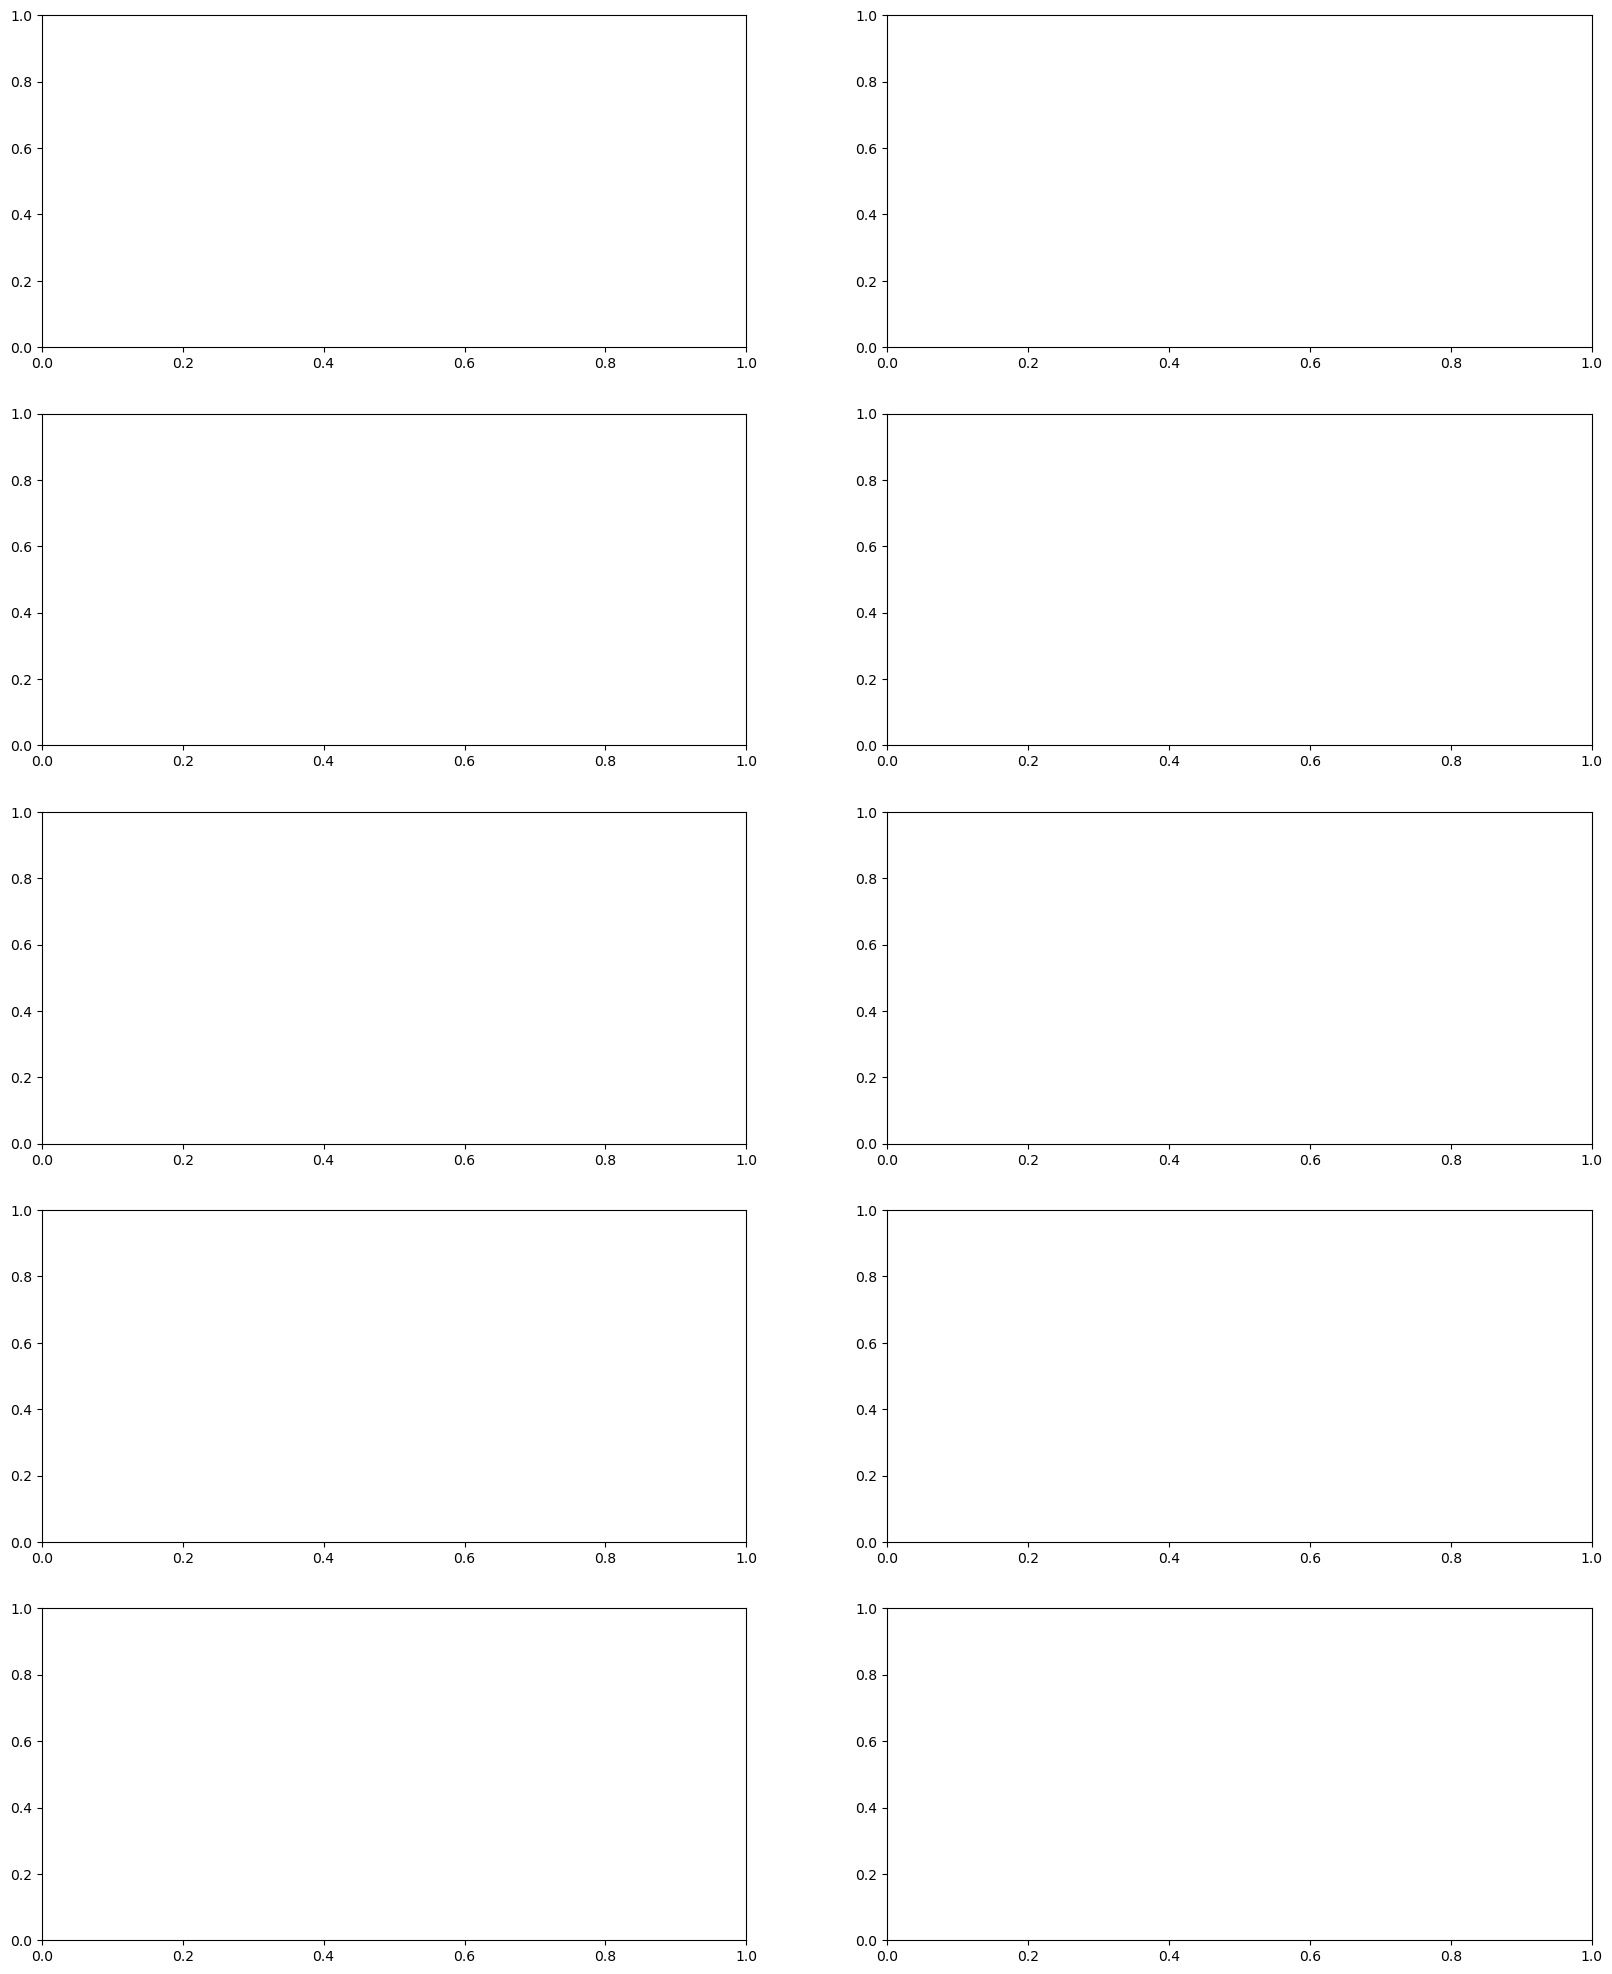

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import glob

# Define the path to the folder containing the CSV files
folder_path = '/Users/manasdubey2022/Desktop/new'

csv_files = glob.glob(os.path.join(folder_path, '*_day_of_*.csv'))
file_paths = csv_files[:10]
# Number of files to plot
N_FILES = len(file_paths)


# Create a tile-based plot for all files in file_paths
fig, axs = plt.subplots(nrows=5, ncols=2, figsize=(20, 25))

for i, file in enumerate(file_paths[:N_FILES]):
    df = pd.read_csv(file, skiprows=0)
    # Strip the leading and trailing whitespaces from the column names
    df.columns = df.columns.str.strip()
    print(df.columns)
    # Strip the leading and trailing whitespaces from the 'Lcl Time' field and convert to datetime format
    df['Lcl Time'] = pd.to_datetime(df['Lcl Time'].str.strip().replace('', pd.NA), format='%H:%M:%S', errors='coerce')
    # Convert 'AltMSL' to numeric, setting errors='coerce' to handle non-numeric values
    df['AltitudeAGL'] = pd.to_numeric(df['AltitudeAGL'], errors='coerce')
    
    # Remove NaN values from 'AltMSL'
    df = df.dropna(subset=['AltitudeAGL'])
    
    row = i // 2
    col = i % 2
    axs[row, col].plot(df['Lcl Time'], df['AltitudeAGL'])
    axs[row, col].set_title(os.path.basename(file))
    axs[row, col].set_xlabel('Local Time')
    axs[row, col].set_ylabel('Altitude AGL (ft)')
    axs[row, col].grid(True)
    # Set Y-axis limits and ticks
    if not df['AltitudeAGL'].empty:
        y_min = df['AltitudeAGL'].min()
        y_max = df['AltitudeAGL'].max()
        y_range = y_max - y_min
        axs[row, col].set_ylim(y_min - 0.1 * y_range, y_max + 0.1 * y_range)
        axs[row, col].set_yticks(np.linspace(y_min, y_max, num=10))

plt.tight_layout()
plt.show()
for i in range(len(file_paths)):
    print(file_paths[i])


In [4]:
#plot a csv column 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import glob

# Define the path to the folder containing the CSV files
folder_path = '/Users/manasdubey2022/Desktop/NGAFID_Data_Processor/data/c37_cleaned_all_agl'

csv_files = glob.glob(os.path.join(folder_path, '*.csv'))
csv_files = [file for file in csv_files if any(x in file for x in ['before_0', 'before_1', '_day_of_', '_after_0_', '_after_1_'])]
print(len(csv_files))

3445


In [13]:
#give some sample files and print the names of the files
sample_files = csv_files[:10]
for file in sample_files:
    print(file)


/Users/manasdubey2022/Desktop/c37_cleaned_all_agl_separated/open_2013_07_13_close_2013_07_13_flight_Fixed Wing_N565ND_before_1_269686_1.csv
/Users/manasdubey2022/Desktop/c37_cleaned_all_agl_separated/open_2013_07_10_close_2013_07_10_flight_Fixed Wing_N524ND_after_1_347099_1.csv
/Users/manasdubey2022/Desktop/c37_cleaned_all_agl_separated/open_2014_02_26_close_2014_02_26_flight_Fixed Wing_N566ND_before_0_471152_1.csv
/Users/manasdubey2022/Desktop/c37_cleaned_all_agl_separated/open_2014_07_08_close_2014_07_08_flight_Fixed Wing_N573ND_day_of_389220_1.csv
/Users/manasdubey2022/Desktop/c37_cleaned_all_agl_separated/open_2017_04_17_close_2017_04_17_flight_Fixed Wing_N731ND_after_0_445282_1.csv
/Users/manasdubey2022/Desktop/c37_cleaned_all_agl_separated/open_2013_06_24_close_2013_07_12_flight_Fixed Wing_N557ND_day_of_490546_7.csv
/Users/manasdubey2022/Desktop/c37_cleaned_all_agl_separated/open_2015_05_26_close_2015_05_27_flight_Fixed Wing_N549ND_before_0_475777_1.csv
/Users/manasdubey2022/Desk

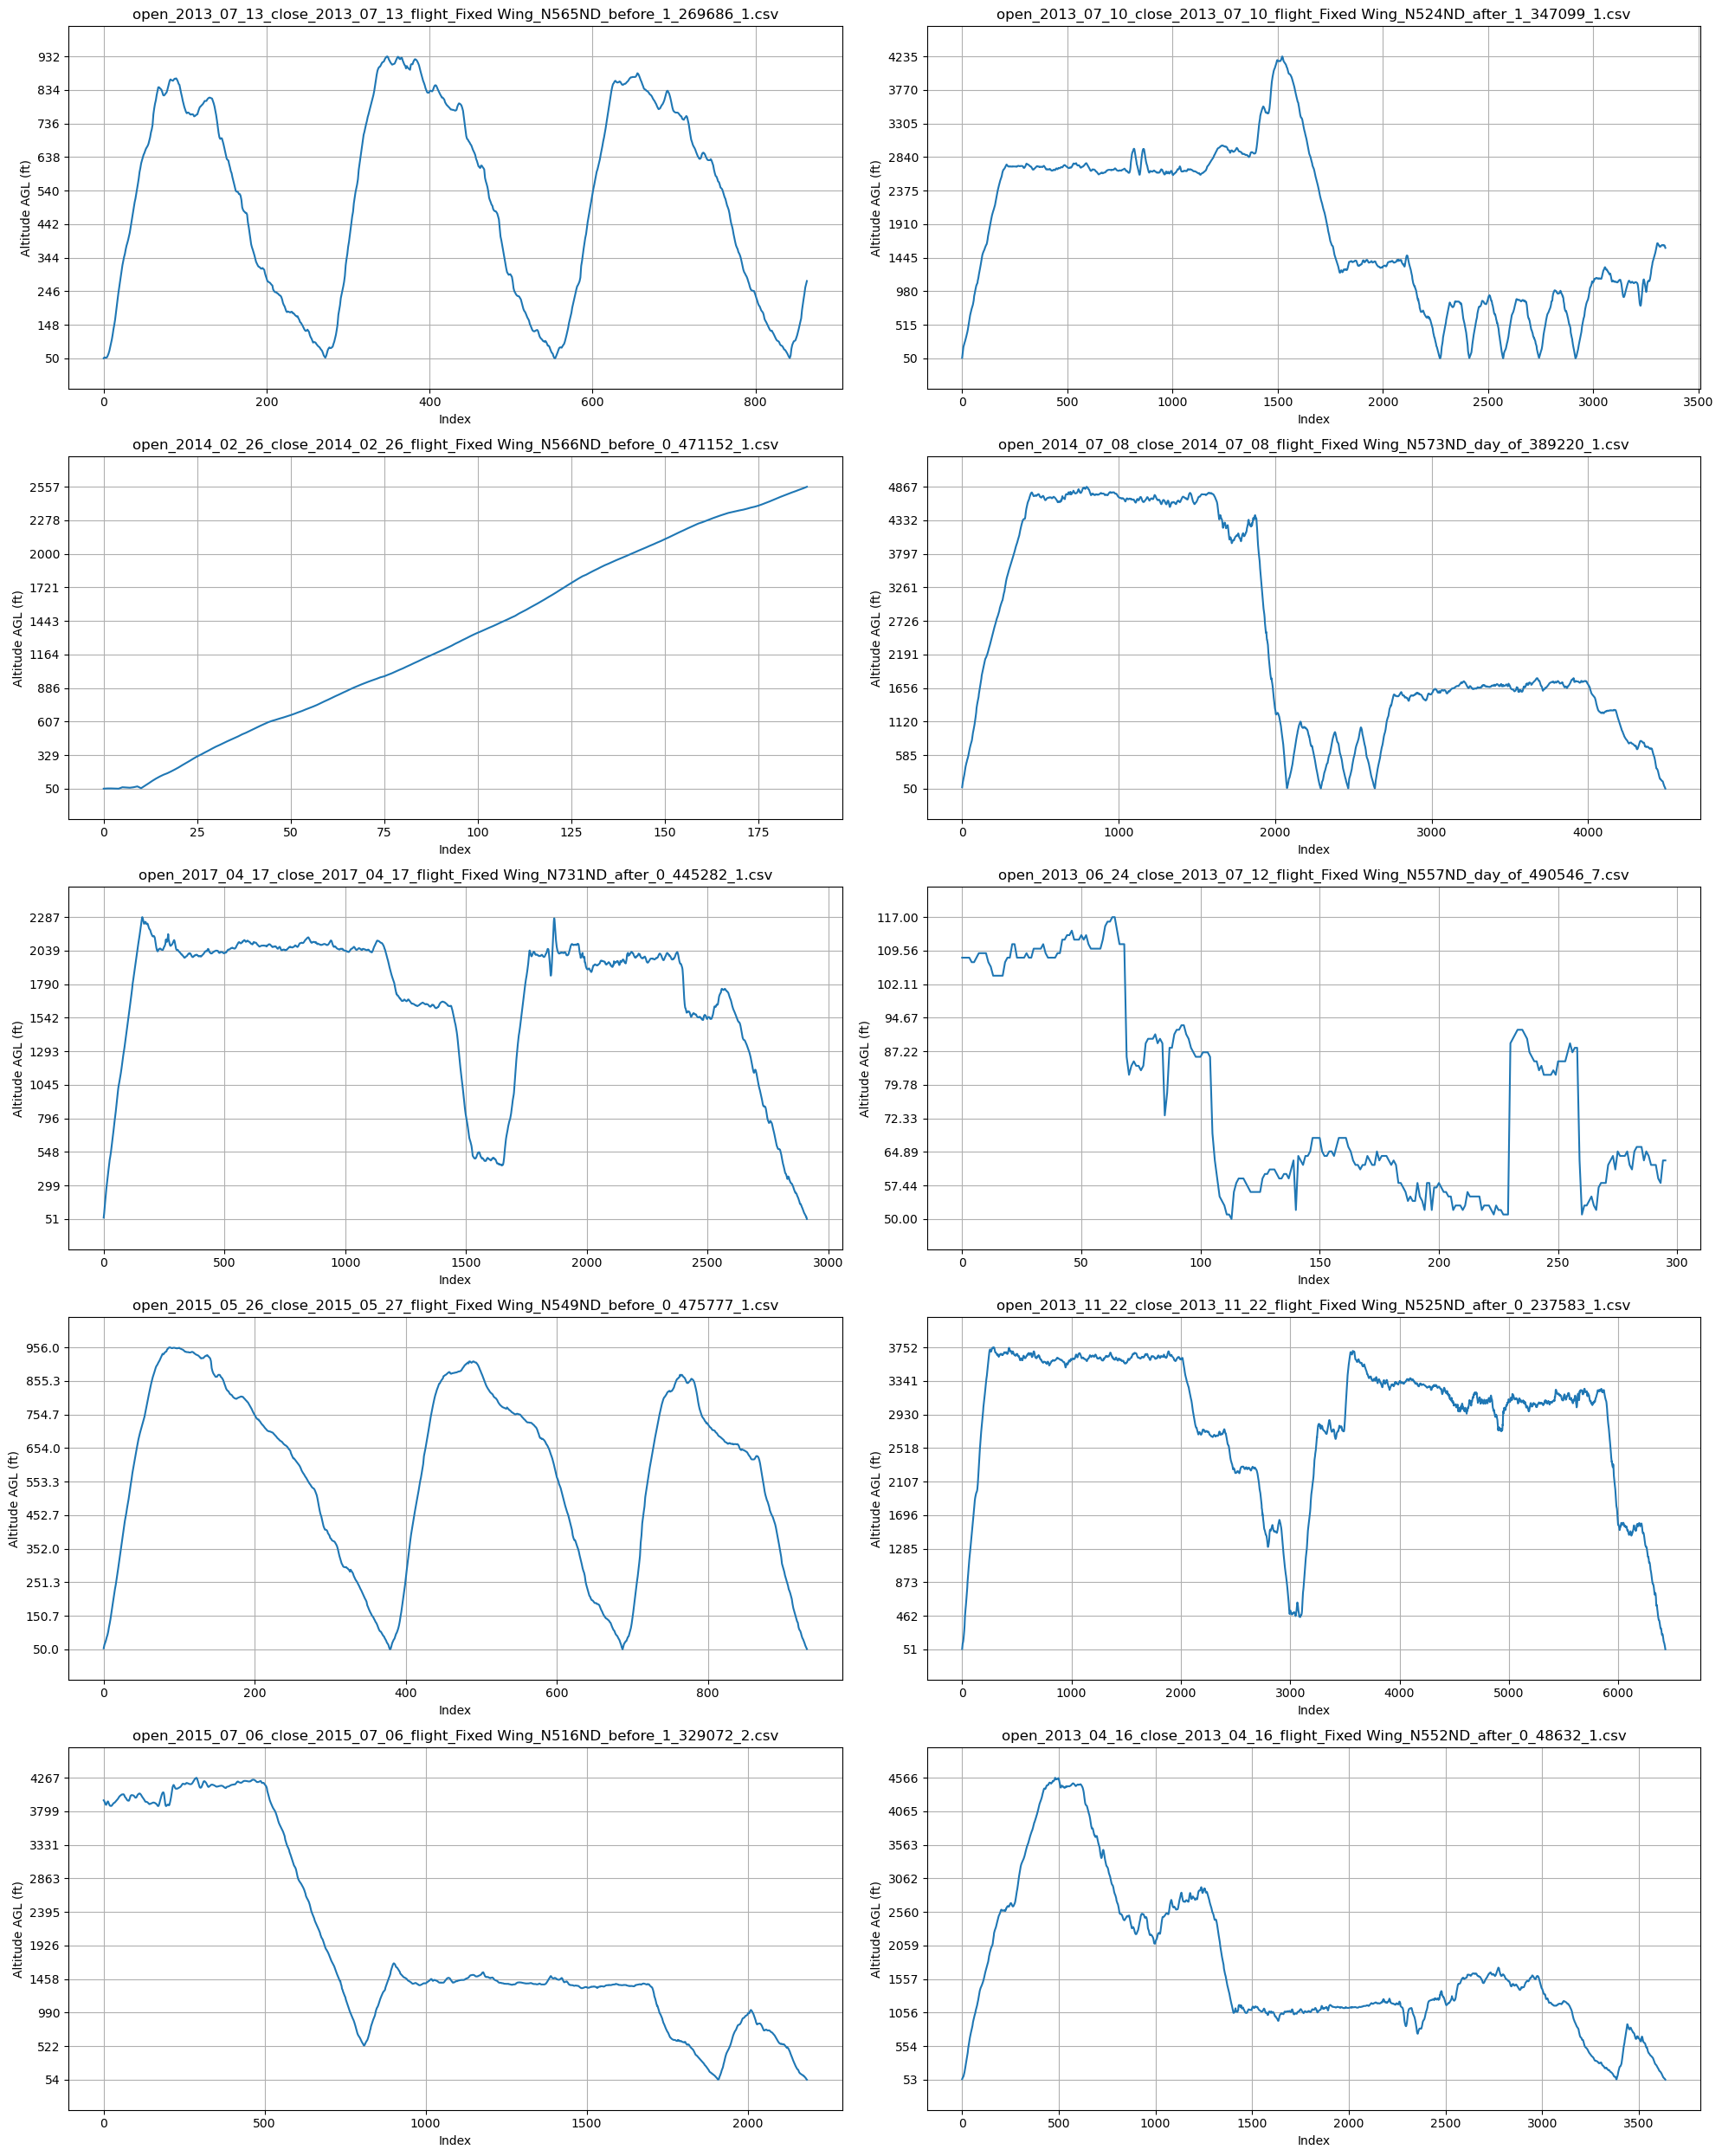

In [14]:

def plot_altitude_profiles(csv_files, n_files=10):
    # Create a tile-based plot for all files in csv_files
    fig, axs = plt.subplots(nrows=5, ncols=2, figsize=(20, 25))

    for i, file in enumerate(csv_files[:n_files]):
        df = pd.read_csv(file, skiprows=0)
        # Strip the leading and trailing whitespaces from the column names
        df.columns = df.columns.str.strip()
        # Convert 'AltitudeAGL' to numeric, setting errors='coerce' to handle non-numeric values
        df['AltitudeAGL'] = pd.to_numeric(df['AltitudeAGL'], errors='coerce')
        
        # Remove NaN values from 'AltitudeAGL'
        df = df.dropna(subset=['AltitudeAGL'])
        
        row = i // 2
        col = i % 2
        axs[row, col].plot(df.index, df['AltitudeAGL'])
        axs[row, col].set_title(os.path.basename(file))
        axs[row, col].set_xlabel('Index')
        axs[row, col].set_ylabel('Altitude AGL (ft)')
        axs[row, col].grid(True)
        # Set Y-axis limits and ticks
        if not df['AltitudeAGL'].empty:
            y_min = df['AltitudeAGL'].min()
            y_max = df['AltitudeAGL'].max()
            y_range = y_max - y_min
            axs[row, col].set_ylim(y_min - 0.1 * y_range, y_max + 0.1 * y_range)
            axs[row, col].set_yticks(np.linspace(y_min, y_max, num=10))

    plt.tight_layout()
    plt.show()

plot_altitude_profiles(csv_files, N_FILES)


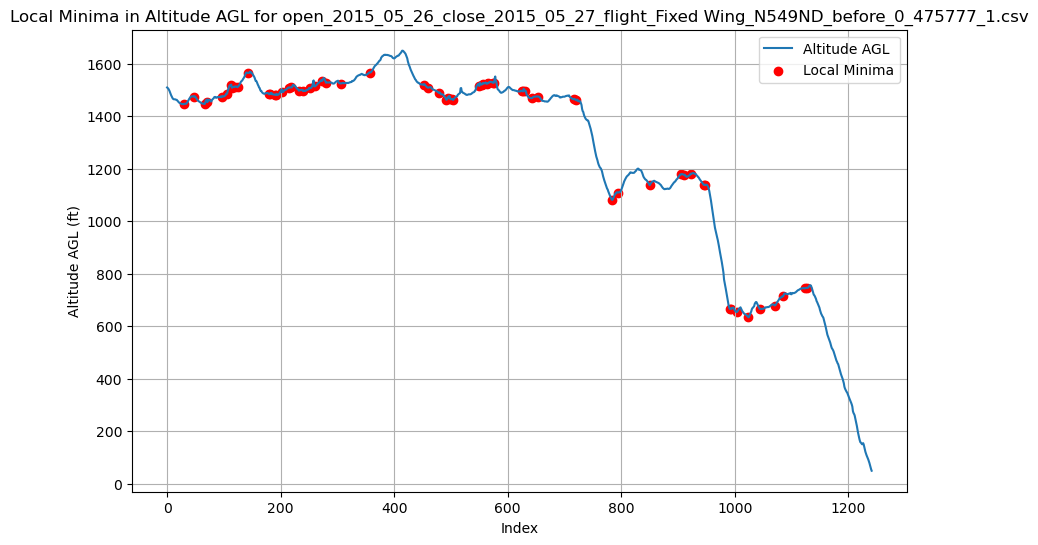

        AltB  BaroA  AltMSL  OAT     IAS  GndSpd    VSpd  Pitch   Roll  LatAc  \
29    2489.5  30.55  2320.4 -2.2  118.14  105.35  -18.69  -0.49  -1.74   0.04   
47    2511.5  30.55  2346.3 -2.0  114.66  101.62    0.84  -0.36  -2.74   0.04   
66    2482.5  30.55  2315.8 -2.0  116.51  103.22  -34.91  -0.52   0.08   0.04   
71    2481.5  30.55  2315.6 -2.0  116.03  102.90   -0.23  -0.16  -1.58   0.04   
96    2503.5  30.55  2338.7 -2.0  113.89  100.24  -52.26  -0.19  -0.55   0.04   
...      ...    ...     ...  ...     ...     ...     ...    ...    ...    ...   
1044  1557.1  30.51  1509.7  0.2   86.62   93.22 -387.91   4.06  11.89   0.01   
1070  1567.1  30.51  1523.0  0.5   80.40   90.48  -70.25   2.79  -1.36   0.00   
1085  1612.1  30.51  1557.9  0.2   83.44   91.20  263.46   4.47   0.62  -0.05   
1123  1629.1  30.51  1583.8  0.2   81.58   90.06  -87.48   3.47  -3.60   0.03   
1128  1639.1  30.51  1585.4  0.2   84.90   93.13  166.46   2.37  -1.59  -0.02   

      ...  RollC  PichC  VS

In [6]:
import pandas as pd
import numpy as np
from scipy.signal import argrelextrema

def find_local_minima(df, column_name):
    """Find all local minima in a given numeric column of a DataFrame."""
    # Ensure the column is numeric
    df[column_name] = pd.to_numeric(df[column_name], errors='coerce')
    
    # Drop NaN values
    df = df.dropna(subset=[column_name])
    
    # Find local minima
    local_minima_indices = argrelextrema(df[column_name].values, np.less)[0]
    
    # Extract the rows corresponding to the local minima
    local_minima_df = df.iloc[local_minima_indices]
    
    return local_minima_df

df = pd.read_csv(csv_files[0], skiprows=0)

# Assuming df is your DataFrame and 'AltitudeAGL' is the column you want to analyze
local_minima_df = find_local_minima(df, 'AltitudeAGL')

# Plot the AltitudeAGL curve
plt.figure(figsize=(10, 6))
plt.plot(df['AltitudeAGL'], label='Altitude AGL')

# Plot the local minima points
plt.scatter(local_minima_df.index, local_minima_df['AltitudeAGL'], color='red', label='Local Minima')

# Display the file name
plt.title(f'Local Minima in Altitude AGL for {os.path.basename(file)}')
plt.xlabel('Index')
plt.ylabel('Altitude AGL (ft)')
plt.legend()
plt.grid(True)
plt.show()

print(local_minima_df)

In [31]:
#one of the files with many sections
folder_path = '/Users/manasdubey2022/Desktop/c37_cleaned_all_agl_separated_50'
csv_files = glob.glob(os.path.join(folder_path, 'open_2013_06_24_close_2013_07_12_flight_Fixed Wing_N557ND_day_of_490546_*'))

In [32]:
for file in csv_files:
    print(file)

/Users/manasdubey2022/Desktop/c37_cleaned_all_agl_separated_50/open_2013_06_24_close_2013_07_12_flight_Fixed Wing_N557ND_day_of_490546_7.csv
/Users/manasdubey2022/Desktop/c37_cleaned_all_agl_separated_50/open_2013_06_24_close_2013_07_12_flight_Fixed Wing_N557ND_day_of_490546_67.csv
/Users/manasdubey2022/Desktop/c37_cleaned_all_agl_separated_50/open_2013_06_24_close_2013_07_12_flight_Fixed Wing_N557ND_day_of_490546_66.csv
/Users/manasdubey2022/Desktop/c37_cleaned_all_agl_separated_50/open_2013_06_24_close_2013_07_12_flight_Fixed Wing_N557ND_day_of_490546_6.csv
/Users/manasdubey2022/Desktop/c37_cleaned_all_agl_separated_50/open_2013_06_24_close_2013_07_12_flight_Fixed Wing_N557ND_day_of_490546_4.csv
/Users/manasdubey2022/Desktop/c37_cleaned_all_agl_separated_50/open_2013_06_24_close_2013_07_12_flight_Fixed Wing_N557ND_day_of_490546_58.csv
/Users/manasdubey2022/Desktop/c37_cleaned_all_agl_separated_50/open_2013_06_24_close_2013_07_12_flight_Fixed Wing_N557ND_day_of_490546_64.csv
/Users/ma

IndexError: index 5 is out of bounds for axis 0 with size 5

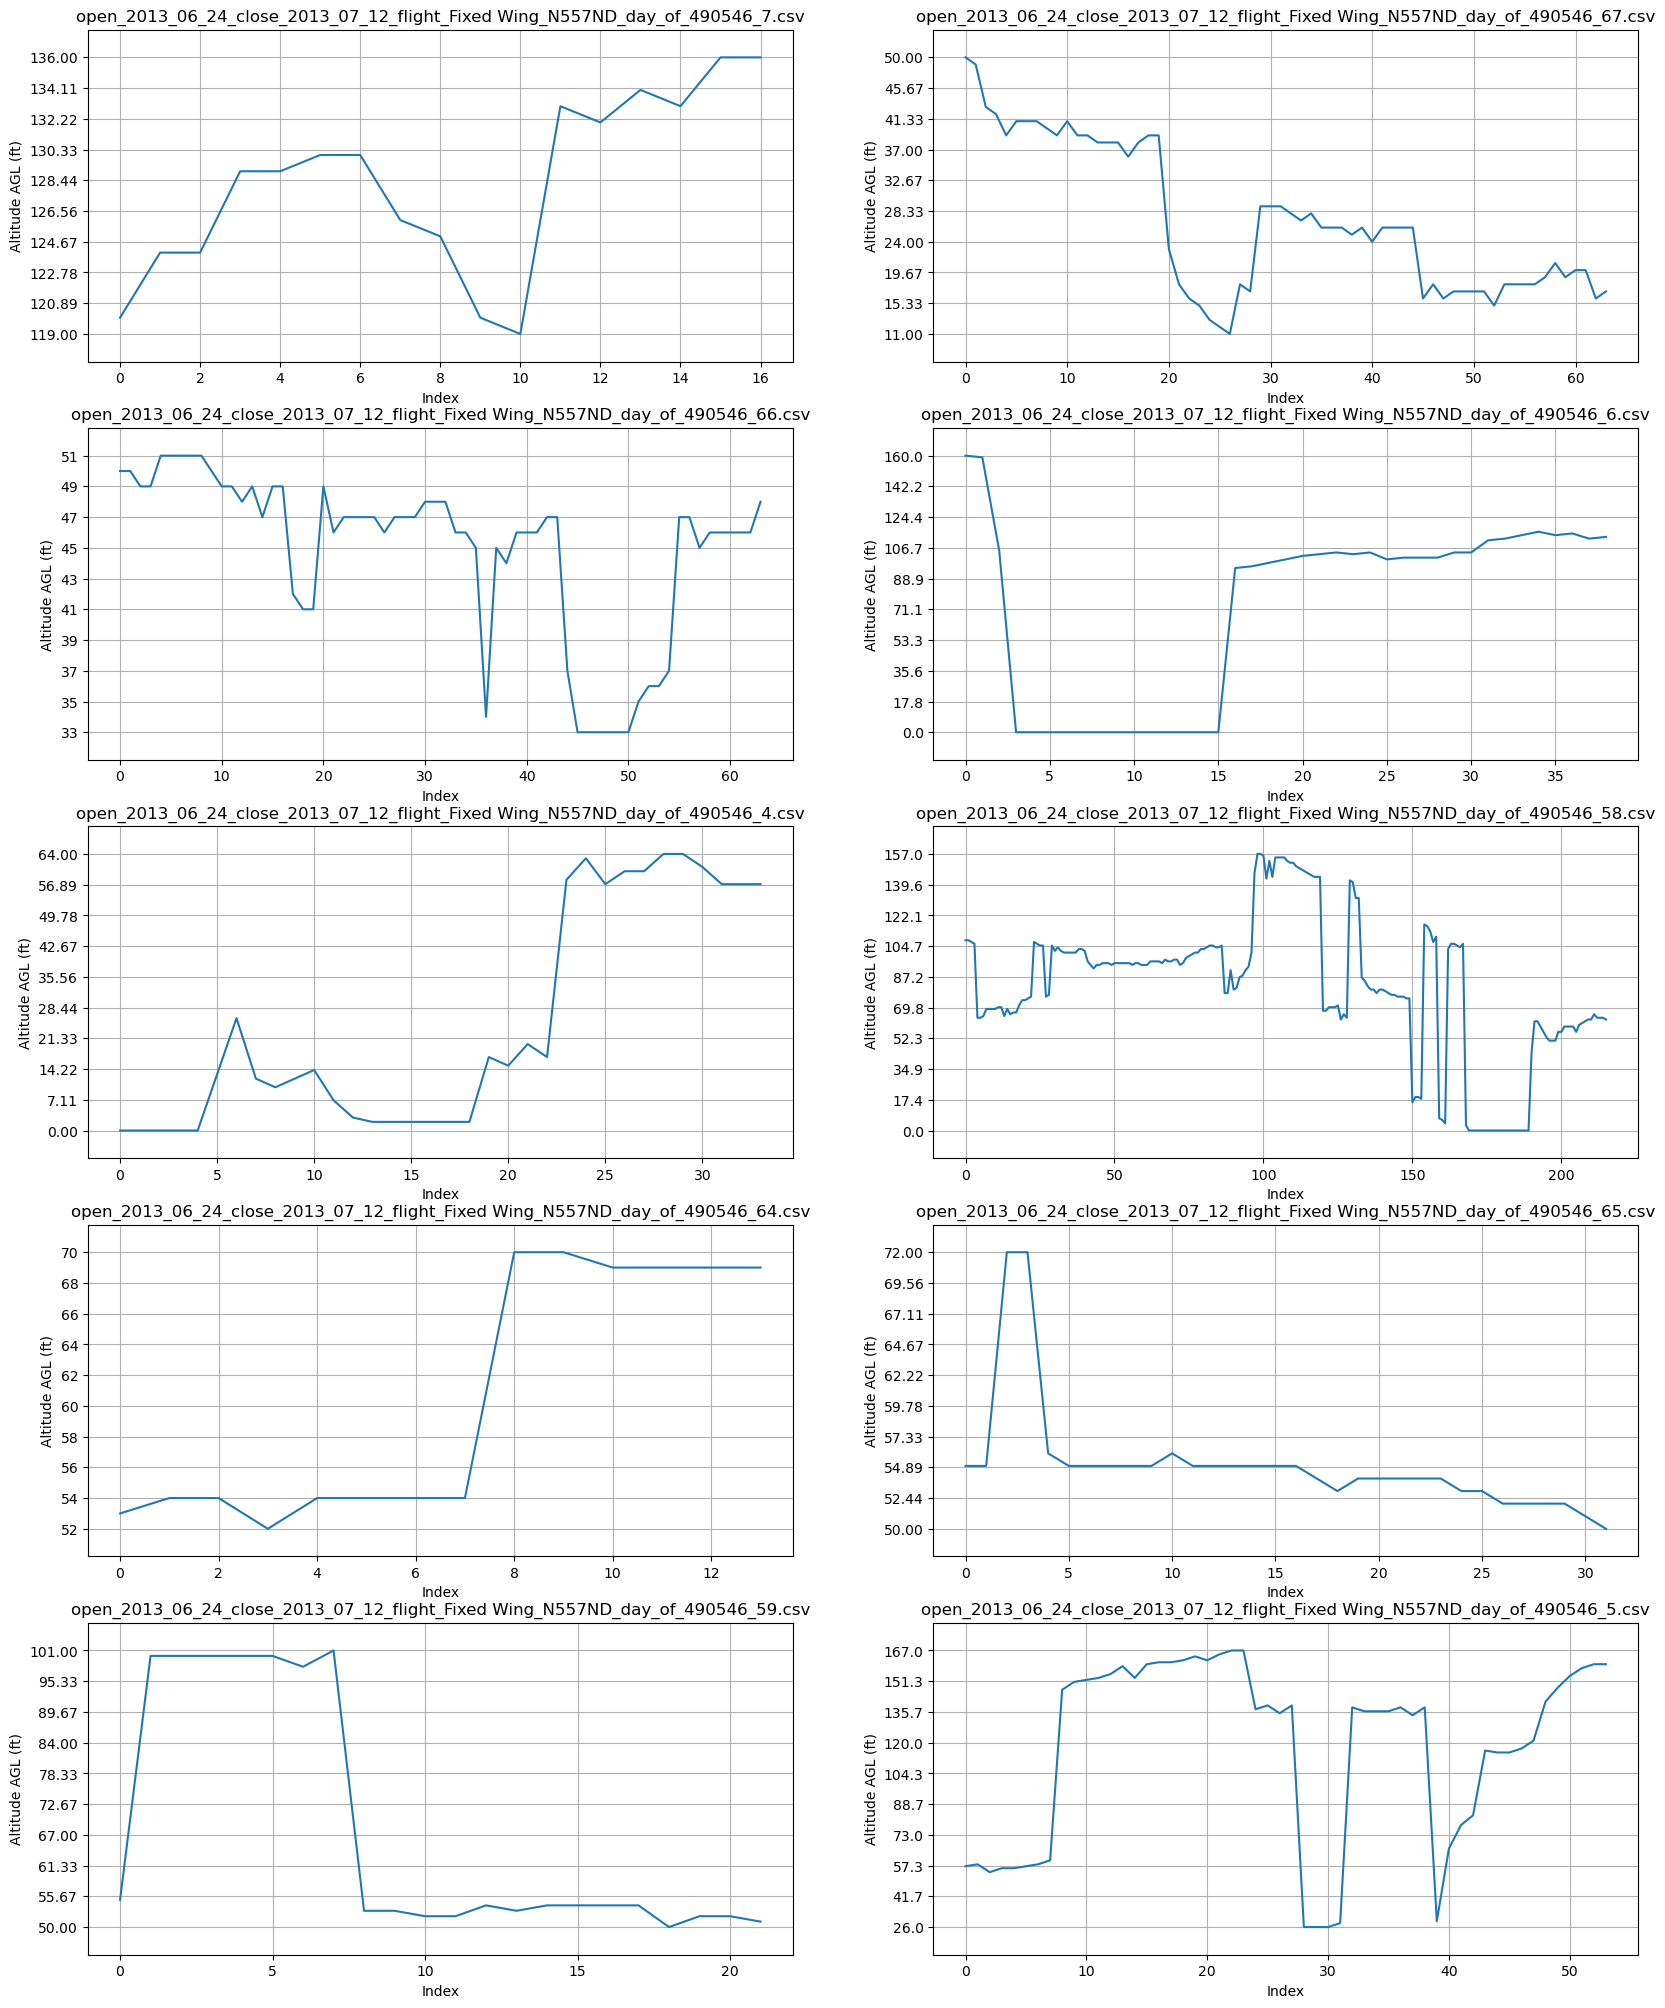

In [33]:
plot_altitude_profiles(csv_files, n_files=len(csv_files))

In [ ]:
folder_path = '/Users/manasdubey2022/Desktop/fake_files_processed'
csv_files = glob.glob(os.path.join(folder_path, '*.csv'))
print(len(csv_files))
def plot_altitude_profiles(csv_files, n_files=10):
	# Calculate the number of rows and columns for the subplot grid
	nrows = (n_files + 1) // 2
	ncols = 2

	# Create a tile-based plot for all files in csv_files
	fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 5 * nrows))

	for i, file in enumerate(csv_files[:n_files]):
		df = pd.read_csv(file, skiprows=0)
		# Strip the leading and trailing whitespaces from the column names
		df.columns = df.columns.str.strip()
		# Convert 'AltitudeAGL' to numeric, setting errors='coerce' to handle non-numeric values
		df['AltitudeAGL'] = pd.to_numeric(df['AltitudeAGL'], errors='coerce')
		
		# Remove NaN values from 'AltitudeAGL'
		df = df.dropna(subset=['AltitudeAGL'])
		
		row = i // ncols
		col = i % ncols
		axs[row, col].plot(df.index, df['AltitudeAGL'])
		axs[row, col].set_title(os.path.basename(file))
		axs[row, col].set_xlabel('Index')
		axs[row, col].set_ylabel('Altitude AGL (ft)')
		axs[row, col].grid(True)
		# Set Y-axis limits and ticks
		if not df['AltitudeAGL'].empty:
			y_min = df['AltitudeAGL'].min()
			y_max = df['AltitudeAGL'].max()
			y_range = y_max - y_min
			axs[row, col].set_ylim(y_min - 0.1 * y_range, y_max + 0.1 * y_range)
			axs[row, col].set_yticks(np.linspace(y_min, y_max, num=10))

	plt.tight_layout()
	plt.show()

plot_altitude_profiles(csv_files, n_files=len(csv_files))

EDA

In [ ]:
import glob
import os

#one of the files with many sections
folder_path = '/Users/manasdubey2022/Desktop/c37_cleaned_all'
csv_files = glob.glob(os.path.join(folder_path, 'open_2013_06_24_close_2013_07_12_flight_Fixed Wing_N557ND_day_of_490546_*'))
